In [ ]:
import json
import pickle
import math
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import sys

sys.path.append("../../")
import gep_problem_operational

DISPLAY_NAMES = {
    ("BEL", "WindOff"): "Belgium Offshore Wind",
    ("BEL", "Gas"): "Belgium Gas",
    ("GER", "Gas"): "Germany Gas",
    ("GER", "SunPV"): "Germany Solar",
    ("FRA", "Nuclear"): "France Nuclear",
    ("FRA", "SunPV"): "France Solar",
}


def load_dist_investment_split(folder_path):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    print(f"Found {len(csv_files)} CSV files in {folder_path}")

    inv_inexact = []
    inv_exact = []

    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        if "investment" not in df.columns or "exact_mode" not in df.columns:
            continue

        for _, row in df.iterrows():
            inv = ast.literal_eval(row["investment"])
            if row["exact_mode"]:
                inv_exact.append(inv)
            else:
                inv_inexact.append(inv)

    inv_inexact = np.array(inv_inexact, dtype=float) if inv_inexact else np.empty((0, 0))
    inv_exact = np.array(inv_exact, dtype=float) if inv_exact else np.empty((0, 0))

    print(f"Inexact iterations: {len(inv_inexact)}, Exact iterations: {len(inv_exact)}")
    return inv_inexact, inv_exact

def plot_investment_ecdf_dist(
    training_data_path,
    benders_csv_path,
    config_path,
    plot_name="Investment Distribution (ECDF)",
    mode="inexact",                  # "both", "exact", "inexact"
    show_train_support=True,       # shaded blue region 0..max_inv_train
    show_train_max_line=False,     # dashed line at max_inv_train
    clip_percentile=None,          # ONLY sets xlim; data is never dropped
    figsize_per_col=4.8,
    figsize_per_row=3.6,
    share_legend=True,
    save_path=None,
):
    training_data = pickle.load(open(training_data_path, "rb"))
    args = json.load(open(config_path, "r"))

    n_instances = training_data.pUnitInvestment.shape[0]
    train_size = int(args["train"] * n_instances)
    Xtr_gen = training_data.pUnitInvestment[:train_size]
    Xtr_gen = Xtr_gen.detach().cpu().numpy() if hasattr(Xtr_gen, "detach") else np.asarray(Xtr_gen)

    inv_inexact, inv_exact = load_dist_investment_split(benders_csv_path)

    generators = list(training_data.G)
    n_generators = len(generators)

    ncols = 2 if n_generators <= 4 else (3 if n_generators <= 9 else 4)
    nrows = math.ceil(n_generators / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_col * ncols, figsize_per_row * nrows))
    axes = np.array(axes).reshape(-1)

    legend_handles, legend_labels = [], []

    def _add_legend(handle, label):
        if label not in legend_labels:
            legend_handles.append(handle); legend_labels.append(label)

    for j in range(n_generators):
        ax = axes[j]
        country, gname = generators[j]
        max_inv_train = float(Xtr_gen[:, j].max())

        series_list = []
        if mode in ("both", "exact") and len(inv_exact) > 0:
            series_list.append(("Investment in Benders (distribution)", inv_exact[:, j], "tab:orange"))
        if mode in ("both", "inexact") and len(inv_inexact) > 0:
            series_list.append(("Investment in Inexact Benders", inv_inexact[:, j], "tab:green"))

        if not series_list:
            ax.set_title(f"{country}-{gname}")
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue

        # blue training support
        if show_train_support:
            patch = ax.axvspan(0, max_inv_train, color="tab:blue", alpha=0.16, zorder=0)
            _add_legend(patch, "Investment in Surrogate Training")
        if show_train_max_line:
            line = ax.axvline(max_inv_train, color="tab:blue", linestyle="--",
                              linewidth=1.8, alpha=0.95)
            _add_legend(line, "Uniform Max Investment")

        # ECDF curve(s) — full data, no dropping
        right_candidates = [max_inv_train]
        for label, raw, color in series_list:
            s = np.sort(np.asarray(raw, dtype=float))
            if len(s) == 0:
                continue
            y = np.arange(1, len(s) + 1) / len(s) * 100.0
            h, = ax.step(s, y, where="post", color=color, linewidth=2.2, zorder=2)
            ax.fill_between(s, 0, y, step="post", color=color, alpha=0.10, zorder=1)
            _add_legend(h, label)

            # xlim source: percentile if requested, else full max
            if clip_percentile is not None:
                right_candidates.append(float(np.percentile(s, clip_percentile)))
            else:
                right_candidates.append(float(s.max()))

        right = max(right_candidates) * 1.08
        ax.set_xlim(0, right)
        ax.set_ylim(0, 105)

        display_name = DISPLAY_NAMES.get((country, gname), f"{country} {gname}")
        ax.set_title(display_name, fontsize=14, pad=6)
        ax.set_xlabel("Investment", fontsize=12)
        ax.set_ylabel("Instances ≤ value (%)", fontsize=12)
        ax.tick_params(axis="both", labelsize=12)
        ax.grid(axis="both", alpha=0.25, linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for k in range(n_generators, len(axes)):
        axes[k].axis("off")

    if share_legend and legend_handles:
        fig.legend(legend_handles, legend_labels, loc="upper center",
                   ncol=len(legend_labels), frameon=False,
                   bbox_to_anchor=(0.5, 0.93), fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.90 if share_legend else 0.95])
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

## 3 Node Case

Found 73 CSV files in ../../outputs/Benders/3Node/Sample_120/iter_logs_Inexact_Refine_D_uniform_single
Inexact iterations: 919, Exact iterations: 4747


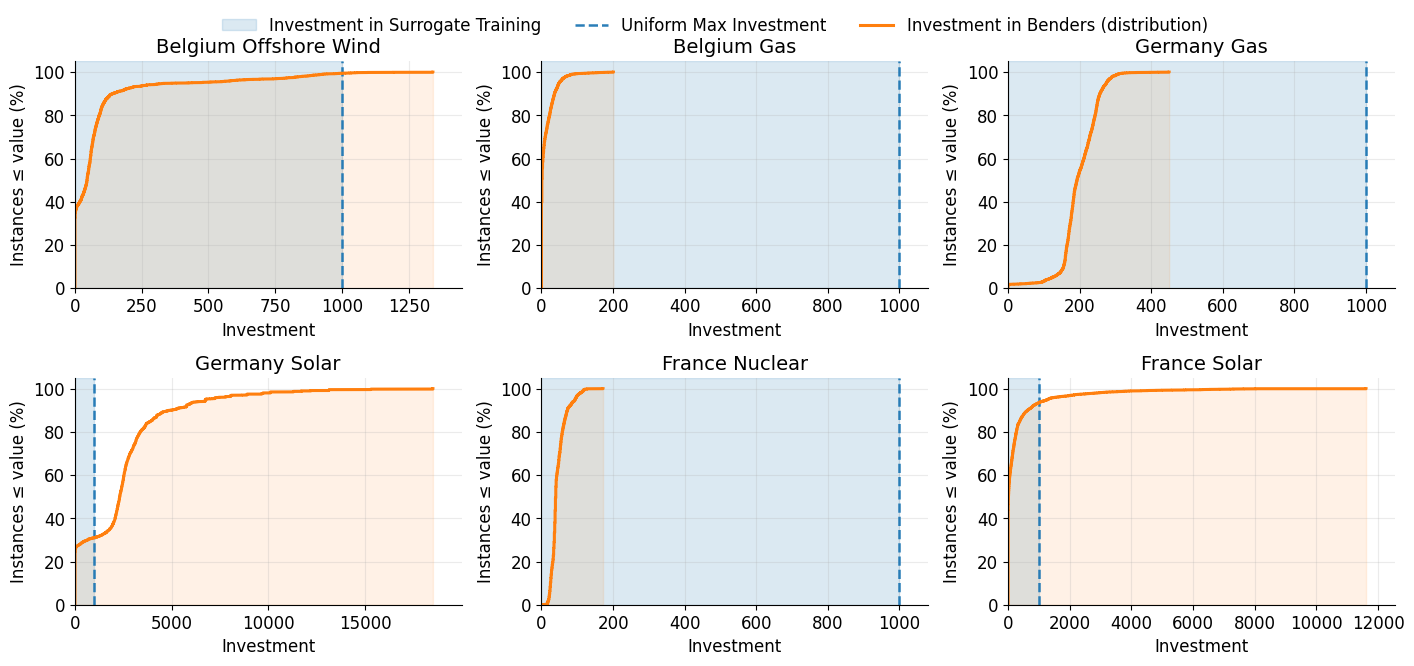

In [72]:


benders_data_path = "../../outputs/Benders/3Node/Sample_120/iter_logs_Inexact_Refine_D_uniform_single"
# benders_data_path = "../../outputs/Benders/3Node/Sample_120/iter_logs_Exact_Exact"
training_data_path = "../../data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
config_path = "../../config.json"




plot_investment_ecdf_dist(
    training_data_path=training_data_path,
    benders_csv_path=benders_data_path,
    config_path=config_path,
    mode="exact",
    show_train_support=True,
    show_train_max_line=True,
)

ls: data/ED_data/Constraint/3Loc: No such file or directory


In [25]:
import matplotlib.pyplot as plt
# Constraint Dataset with no Lower Bound
benders_data_path = "../../outputs/Benders/3Node/iter_logs_inexact_refine_ConstNoLB2"
training_data_path = "../../data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl"
config_path = "../../config.json"

plot_investment_dist(training_data_path, benders_data_path, 
                     config_path, plot_name=" 3 Node: Investment Distribution in Benders vs Constraint Training Data")

FileNotFoundError: [Errno 2] No such file or directory: '../../data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl'

In [51]:
import matplotlib.pyplot as plt
# Constraint Dataset with no Lower Bound
benders_data_path = "../../outputs/Benders/3Node/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10_ConstLB.csv"
training_data_path = "../../data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbTrue.pkl"
# training_data_path2 = "../../data/ED_data/Constraint/TestLB.pkl"
config_path = "../../config.json"

plot_investment_dist(training_data_path, benders_data_path, 
                     config_path, plot_name="Investment Distribution, 3 Node Constraint w/ LB Training Data")

FileNotFoundError: [Errno 2] No such file or directory: '../../data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbTrue.pkl'

## Plot investment bound for Multi Dataset

In [46]:
def _train_max_per_gen(training_data_path, config_path):
    """Per-generator max investment in the training set for one strategy."""
    training_data = pickle.load(open(training_data_path, "rb"))
    args = json.load(open(config_path, "r"))
    n_instances = training_data.pUnitInvestment.shape[0]
    train_size = int(args["train"] * n_instances)
    Xtr = training_data.pUnitInvestment[:train_size]
    Xtr = Xtr.detach().cpu().numpy() if hasattr(Xtr, "detach") else np.asarray(Xtr)
    generators = list(training_data.G)
    return {g: float(Xtr[:, j].max()) for j, g in enumerate(generators)}, generators

def plot_investment_ecdf_multi(
    method_training_paths,
    config_path,
    benders_csv_path,
    mode="exact",
    method_colors=None,
    coincide_tol=1e-3,
    annotate_pct=True,
    xlim_right=None,
    figsize_per_col=4.8,
    figsize_per_row=3.6,
    save_path=None,
):
    labels = list(method_training_paths.keys())
    if method_colors is None:
        cycle = ["tab:blue", "tab:green", "tab:red", "tab:purple", "tab:brown"]
        method_colors = {lab: cycle[i % len(cycle)] for i, lab in enumerate(labels)}

    maxes_by_method, generators = {}, None
    for lab, path in method_training_paths.items():
        maxes, gens = _train_max_per_gen(path, config_path)
        maxes_by_method[lab] = maxes
        generators = gens if generators is None else generators

    inv_inexact, inv_exact = load_dist_investment_split(benders_csv_path)
    inv = inv_exact if mode == "exact" else inv_inexact

    n = len(generators)
    ncols = 2 if n <= 4 else 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_col * ncols, figsize_per_row * nrows))
    axes = np.array(axes).reshape(-1)

    for j, (country, gname) in enumerate(generators):
        ax = axes[j]
        series = np.sort(np.asarray(inv[:, j], dtype=float))
        if len(series) == 0:
            ax.axis("off"); continue

        ecdf_y = np.arange(1, len(series) + 1) / len(series) * 100.0
        ax.step(series, ecdf_y, where="post", color="tab:orange",
                linewidth=2.2, zorder=2, label="Investment in Benders (distribution)")
        ax.fill_between(series, 0, ecdf_y, step="post",
                        color="tab:orange", alpha=0.12, zorder=1)

        # cluster coinciding bounds (same logic as the histogram version)
        vals = [(lab, maxes_by_method[lab].get((country, gname))) for lab in labels]
        vals = [(lab, v) for lab, v in vals if v is not None]
        clusters = []
        for lab, v in sorted(vals, key=lambda x: x[1]):
            placed = False
            for cl in clusters:
                if abs(v - cl[0]) <= coincide_tol * max(abs(v), 1.0):
                    cl[1].append(lab); placed = True; break
            if not placed:
                clusters.append([v, [lab]])

        line_vals = [cl[0] for cl in clusters]
        right = xlim_right if xlim_right is not None else max([series.max()] + line_vals) * 1.08
        ax.set_xlim(0, right)
        ax.set_ylim(0, 105)

        for value, members in clusters:
            color = "0.30" if len(members) > 1 else method_colors[members[0]]
            ax.axvline(value, color=color, linestyle="--", linewidth=2.0, zorder=3)
            if annotate_pct:
                pct_below = float((series <= value).mean() * 100.0)
                x = min(value, right * 0.985)
                near_edge = x > right * 0.7
                ax.text(x + (-1 if near_edge else 1) * right * 0.01,
                        50, f"{value:,.0f}",
                        rotation=90, va="center",
                        ha="right" if near_edge else "left",
                        fontsize=11, color=color, alpha=0.9)

        display = DISPLAY_NAMES.get((country, gname), f"{country} {gname}")
        ax.set_title(display, fontsize=16, pad=6)
        ax.set_xlabel("Investment", fontsize=14)
        ax.set_ylabel("Instances ≤ value (%)", fontsize=14)
        ax.tick_params(axis="both", labelsize=13)
        ax.grid(axis="both", alpha=0.25, linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for k in range(n, len(axes)):
        axes[k].axis("off")

    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color="tab:orange", linewidth=2.2)]
    leg_labels = ["Investment in Benders (distribution)"]
    for lab in labels:
        handles.append(Line2D([0], [0], color=method_colors[lab], linestyle="--", linewidth=2.0))
        leg_labels.append(lab)
    handles.append(Line2D([0], [0], color="0.30", linestyle="--", linewidth=2.0))
    leg_labels.append("Shared bound (remaining methods)")
    fig.legend(handles, leg_labels, loc="upper center", ncol=len(leg_labels),
               frameon=False, bbox_to_anchor=(0.5, 0.99), fontsize=13)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

Found 73 CSV files in ../../outputs/Benders/3Node/Sample_120/iter_logs_Inexact_Refine_D_uniform_single
Inexact iterations: 919, Exact iterations: 4747


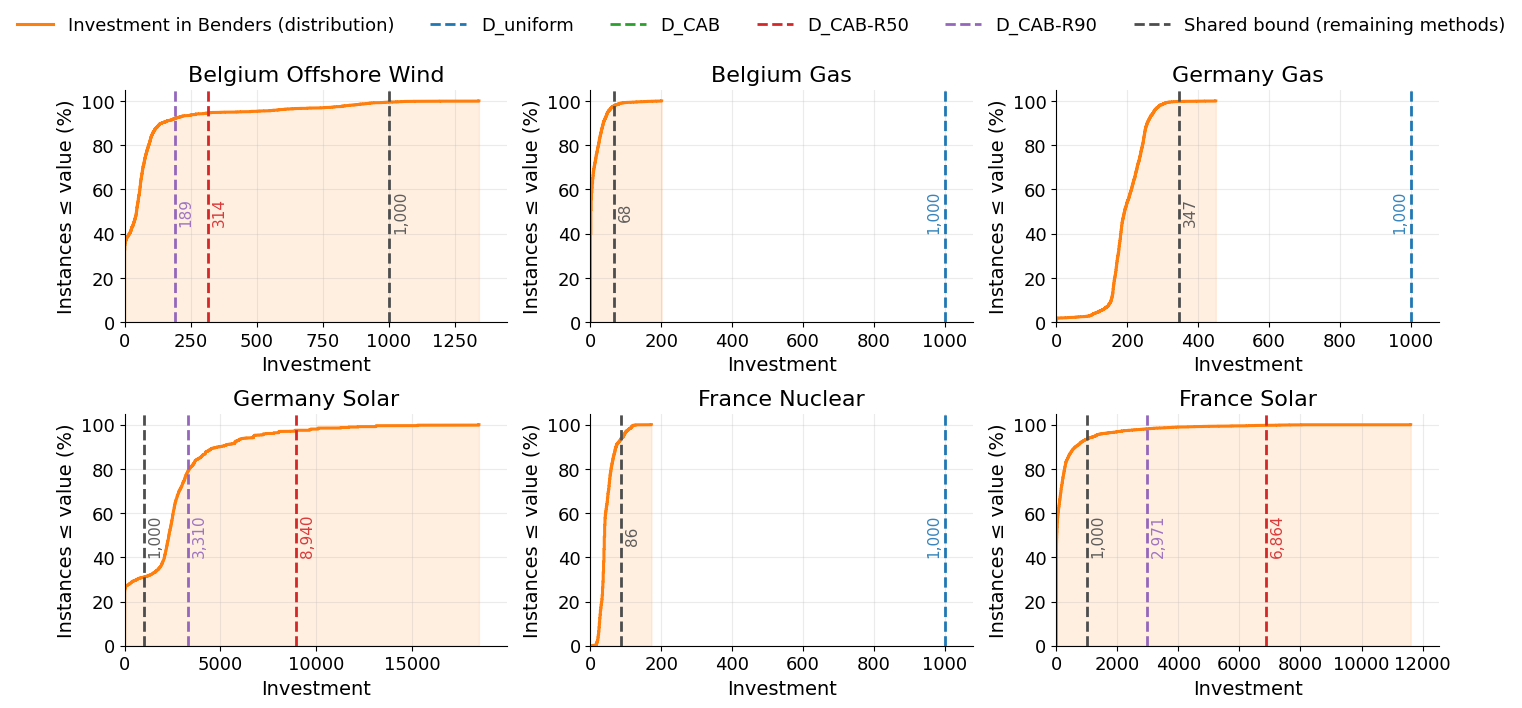

In [63]:

#benders_data_path = "../../outputs/Benders/3Node/Sample_1752/iter_logs_Exact_Exact"
benders_data_path = "../../outputs/Benders/3Node/Sample_120/iter_logs_Inexact_Refine_D_uniform_single"
plot_investment_ecdf_multi(
    method_training_paths={
        # "D_uniform / D_CAB": ".../uniform.pkl",
        "D_uniform":         "../../data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl",
        "D_CAB":             "../../data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl",   
        "D_CAB-R50":         "../../data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc50_Label.pkl",
        "D_CAB-R90":         "../../data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc90_Label.pkl",
    },
    config_path=config_path,
    benders_csv_path=benders_data_path,
    # annotate_lines=True,
    mode="exact",
    save_path="investment-bound-plot.png",
)

Found 73 CSV files in ../../outputs/Benders/3Node/Sample_120/iter_logs_Inexact_Refine_D_CAB_full
Inexact iterations: 293, Exact iterations: 423


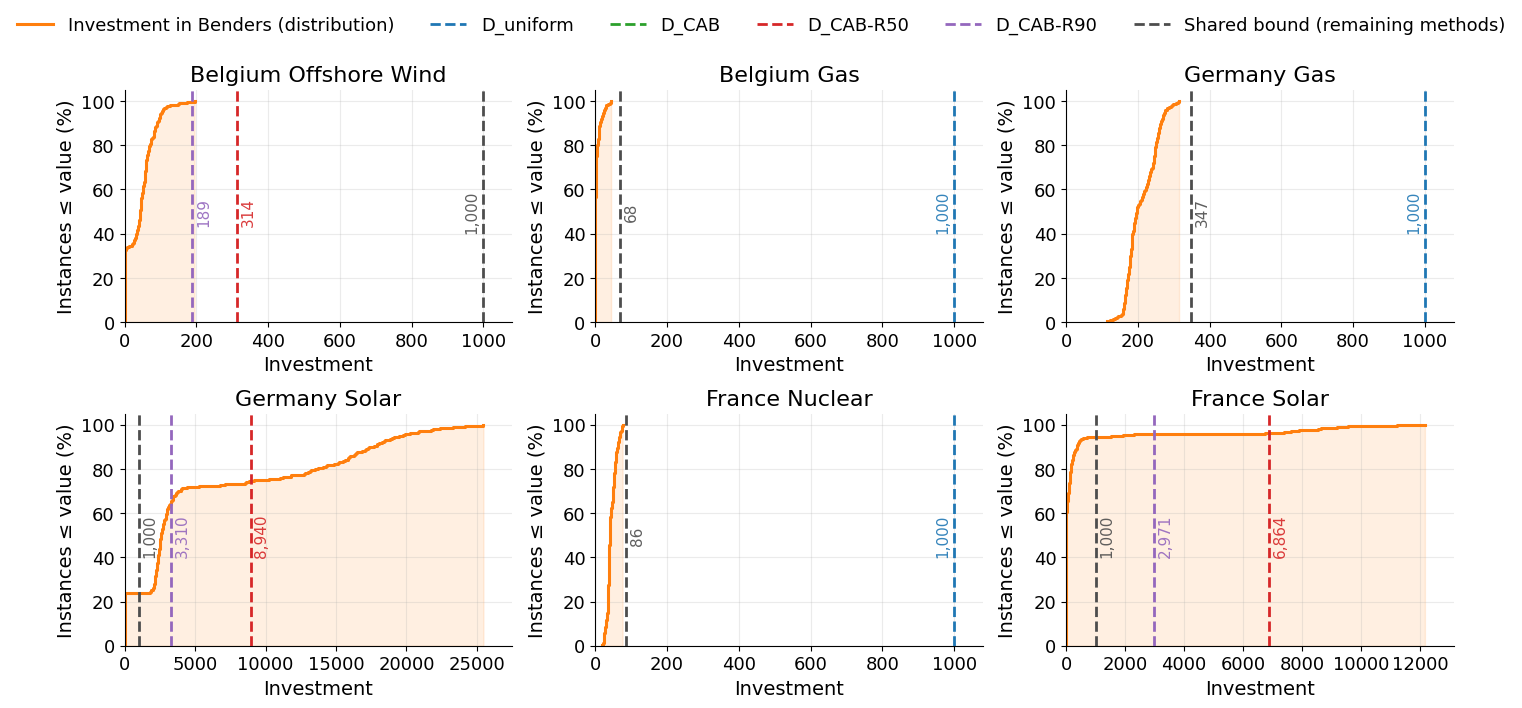

In [61]:

# benders_data_path = "../../outputs/Benders/3Node/Sample_1752/iter_logs_Exact_Exact_full"
benders_data_path = "../../outputs/Benders/3Node/Sample_120/iter_logs_Inexact_Refine_D_CAB_full"
plot_investment_ecdf_multi(
    method_training_paths={
        # "D_uniform / D_CAB": ".../uniform.pkl",
        "D_uniform":         "../../data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl",
        "D_CAB":             "../../data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl",   
        "D_CAB-R50":         "../../data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc50_Label.pkl",
        "D_CAB-R90":         "../../data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint10000_smp15_GenConst_lbFalse_renewPerc90_Label.pkl",
    },
    config_path=config_path,
    benders_csv_path=benders_data_path,
    # annotate_lines=True,
    mode="exact",
    save_path="investment-bound-plot.png",
)

## 5 Node Case

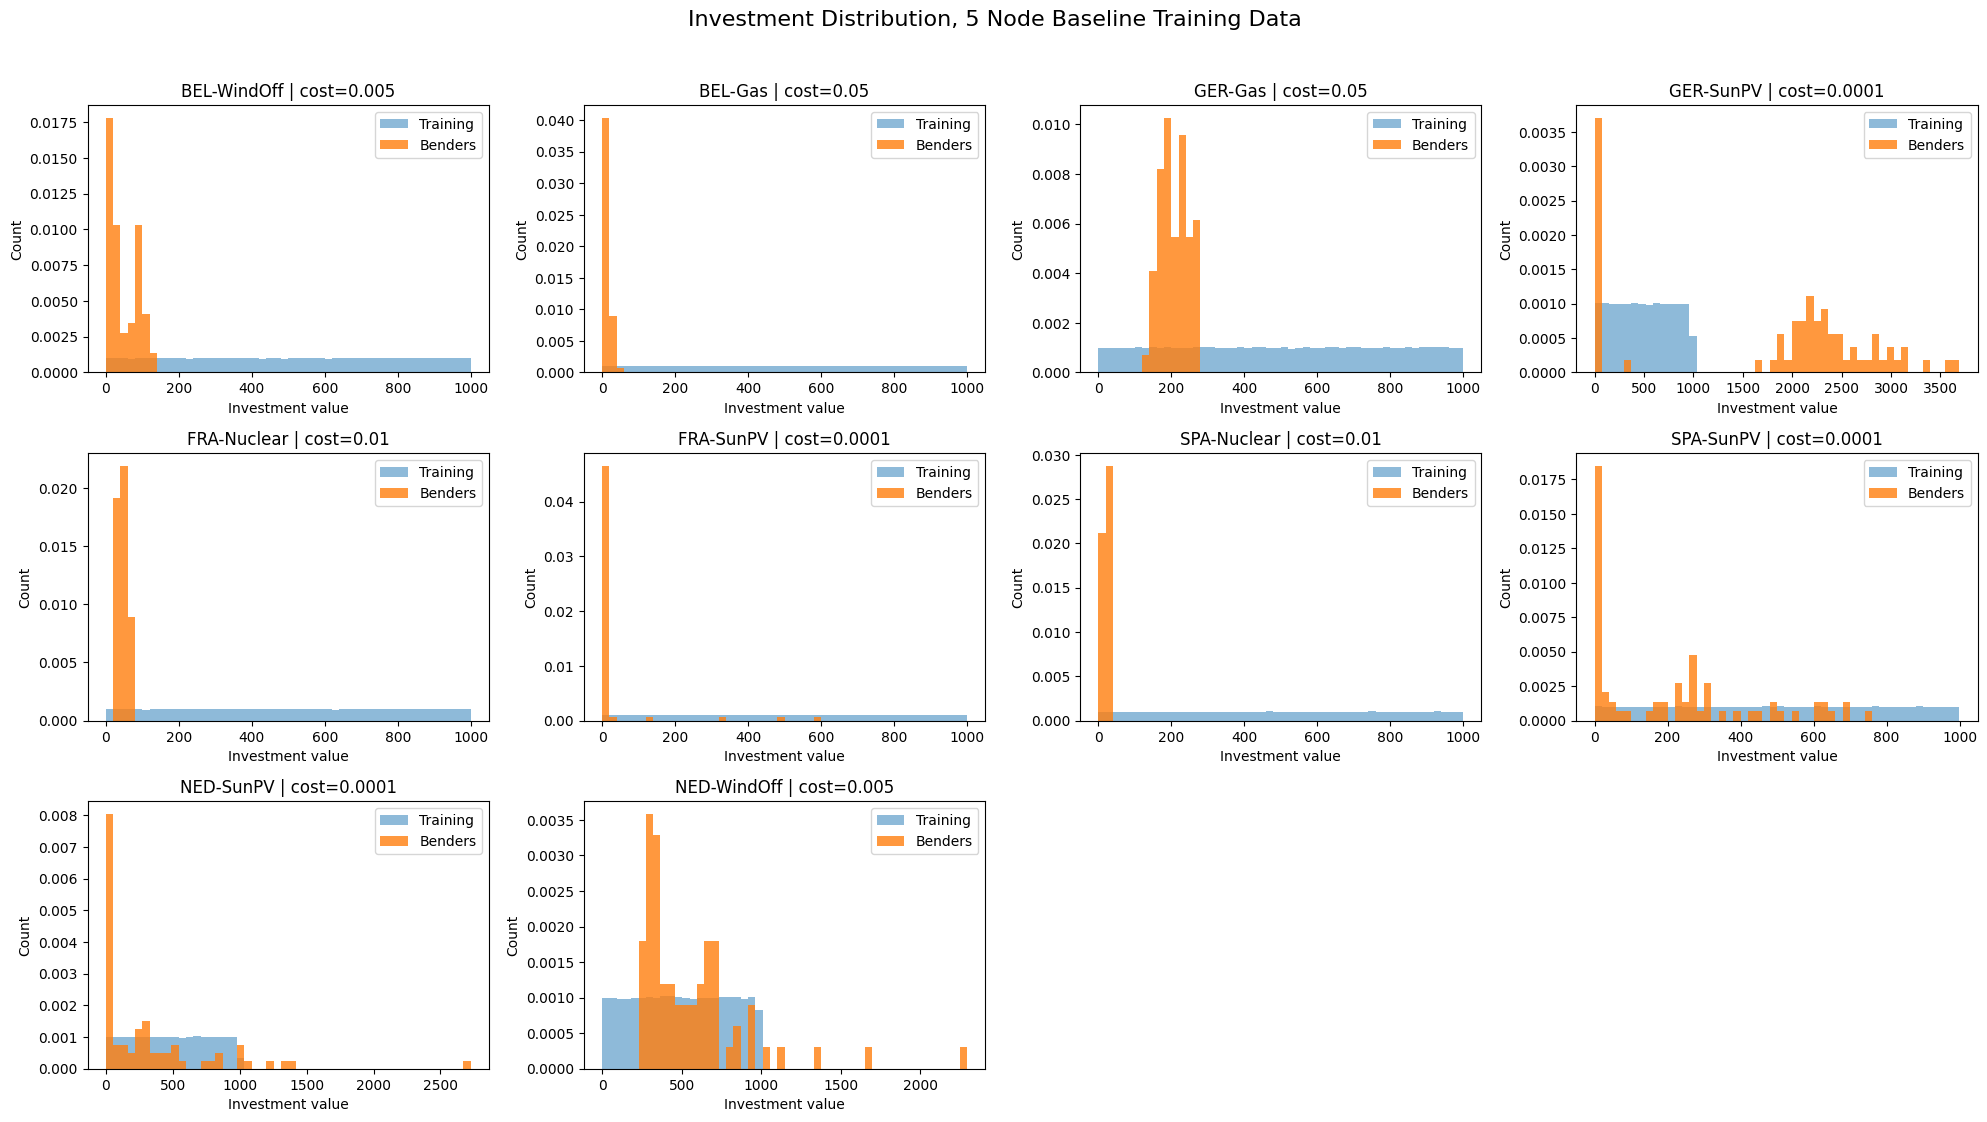

In [44]:
import matplotlib.pyplot as plt

benders_data_path = "../../outputs/Benders/5Node/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10_Baseline.csv"
training_data_path = "../../data/ED_data/ED_NB-G-F-S-N_GB2-G2-F2-S2-N2_L6_c0_s0_p0_smp15.pkl"
config_path = "../../config-5node.json"

plot_investment_dist(training_data_path, benders_data_path, 
                     config_path, plot_name="Investment Distribution, 5 Node Baseline Training Data")

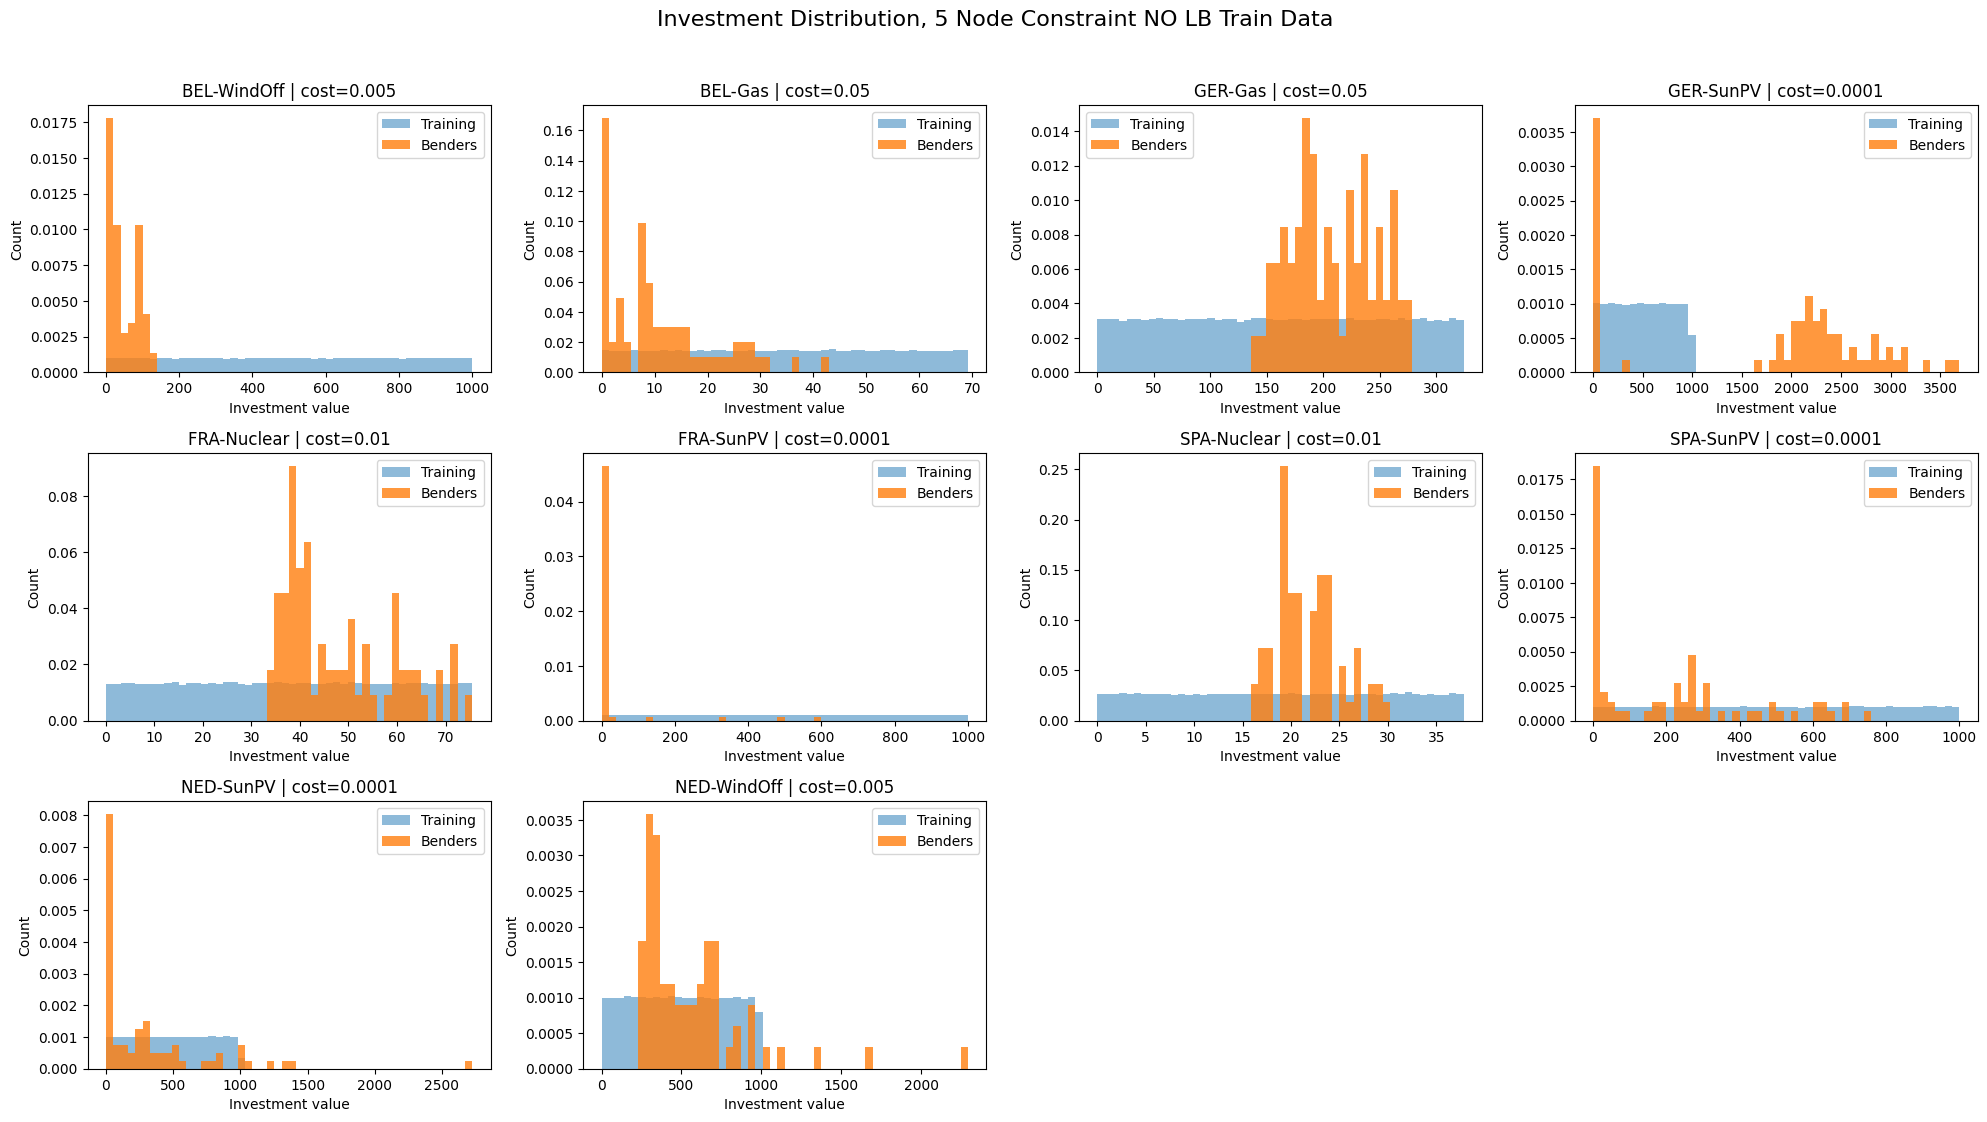

In [45]:
benders_data_path = "../../outputs/Benders/5Node/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10_ConstNoLB.csv"
training_data_path = "../../data/ED_data/Constraint/ED_NB-G-F-S-N_GB2-G2-F2-S2-N2_L6_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse.pkl"
config_path = "../../config-5node.json"

plot_investment_dist(training_data_path, benders_data_path, 
                     config_path, plot_name="Investment Distribution, 5 Node Constraint NO LB Train Data")

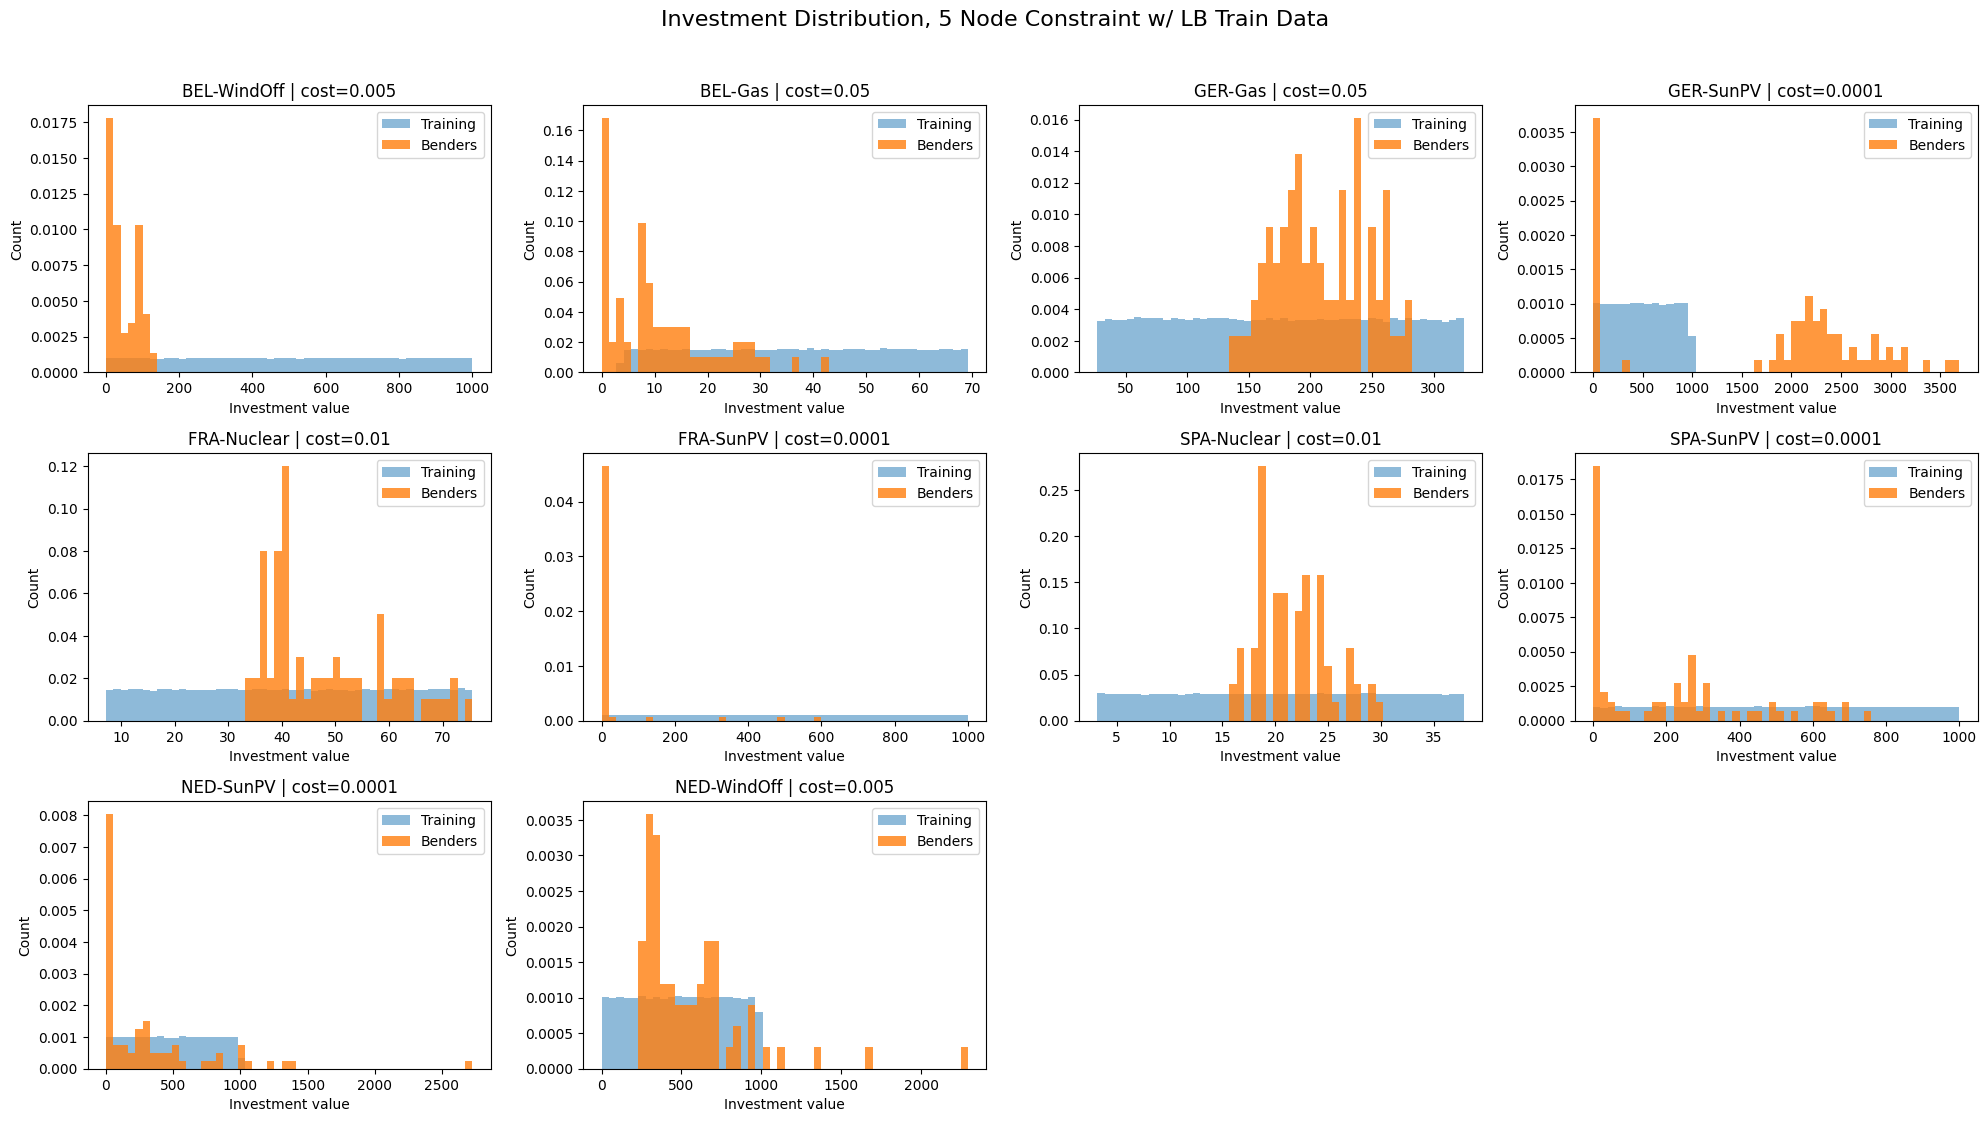

In [46]:
benders_data_path = "../../outputs/Benders/5Node/experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10_ConstLB.csv"
training_data_path = "../../data/ED_data/Constraint/ED_NB-G-F-S-N_GB2-G2-F2-S2-N2_L6_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbTrue.pkl"
config_path = "../../config-5node.json"

plot_investment_dist(training_data_path, benders_data_path, 
                     config_path, plot_name="Investment Distribution, 5 Node Constraint w/ LB Train Data")

### Add a line to test out the data generation limit

In [9]:
import numpy as np

# collect all time indices available for these locations
times = sorted({t for (loc, t) in training_data.pDemand.keys() if loc in locations})
T = len(times)

# build demand matrix [3, T]
D = np.zeros((len(locations), T), dtype=float)

for i, loc in enumerate(locations):
    for j, t in enumerate(times):
        D[i, j] = training_data.pDemand[(loc, t)]

print("locations:", locations)
print("T =", T, "times[0:5] =", times[:5])
print("D shape:", D.shape)
D_max = D.max(axis=1)
print(D_max.shape) # (3,)


locations: ['BEL', 'GER', 'FRA']
T = 8760 times[0:5] = [1, 2, 3, 4, 5]
D shape: (3, 8760)
(3,)


In [10]:
for (i, j) in training_data.L:
    exp_ij = training_data.pExpCap.get((i, j), 0.0)
    exp_ji = training_data.pExpCap.get((j, i), 0.0)

    imp_ij = training_data.pImpCap.get((i, j), 0.0)
    imp_ji = training_data.pImpCap.get((j, i), 0.0)

    print(f"Line {i} <-> {j}")
    print(f"  export {i} -> {j}: {exp_ij}")
    print(f"  export {j} -> {i}: {exp_ji}")
    print(f"  import {i} <- {j}: {imp_ij}")
    print(f"  import {j} <- {i}: {imp_ji}")
    print("-" * 40)

Line BEL <-> GER
  export BEL -> GER: 2380
  export GER -> BEL: 0.0
  import BEL <- GER: 2000
  import GER <- BEL: 0.0
----------------------------------------
Line BEL <-> FRA
  export BEL -> FRA: 2800
  export FRA -> BEL: 0.0
  import BEL <- FRA: 4300
  import FRA <- BEL: 0.0
----------------------------------------
Line GER <-> FRA
  export GER -> FRA: 4800
  export FRA -> GER: 0.0
  import GER <- FRA: 5180
  import FRA <- GER: 0.0
----------------------------------------


In [11]:
from collections import defaultdict

tot_incident = defaultdict(float)

for (a, b) in training_data.L:

    exp_cap_a = float(training_data.pExpCap.get((a, b), 0.0))
    exp_cap_b = float(training_data.pImpCap.get((a, b), 0.0))
    print(f"Line {a} <-> {b}: exp_cap {exp_cap_a} / {exp_cap_b}")
    tot_incident[a] += exp_cap_a
    tot_incident[b] += exp_cap_b

for loc in locations:
    print(f"{loc}: total_incident_cap = {tot_incident[loc]:.1f}")



Line BEL <-> GER: exp_cap 2380.0 / 2000.0
Line BEL <-> FRA: exp_cap 2800.0 / 4300.0
Line GER <-> FRA: exp_cap 4800.0 / 5180.0
BEL: total_incident_cap = 5180.0
GER: total_incident_cap = 6800.0
FRA: total_incident_cap = 9480.0


In [12]:
import numpy as np

# make sure D_max is flat (3,)
D_max_flat = np.asarray(D_max).reshape(-1)

rhs_limit = {}

for i, loc in enumerate(locations):
    rhs_limit[loc] = D_max_flat[i] + tot_incident[loc]

print("RHS limits (Demand max + Export cap):")
for loc, val in rhs_limit.items():
    print(f"{loc}: {val:.3f}")

RHS limits (Demand max + Export cap):
BEL: 14070.114
GER: 74262.985
FRA: 81411.626


In [13]:
gen_unit_cap = {
g: training_data.pUnitCap[g]
for g in generators
}


print(gen_unit_cap)

{('BEL', 'WindOff'): 100, ('BEL', 'Gas'): 250, ('GER', 'Gas'): 250, ('GER', 'SunPV'): 50, ('FRA', 'Nuclear'): 1000, ('FRA', 'SunPV'): 50}


In [14]:
import numpy as np

u_rhs = np.array(
    [rhs_limit[loc] / gen_unit_cap[(loc, tech)]
     for (loc, tech) in generators],
    dtype=float
)

print("u_g upper bounds (in generator order):")
for g, val in zip(generators, u_rhs):
    print(f"{g}: {val:.3f}")

print("shape:", u_rhs.shape)  # (6,)

u_g upper bounds (in generator order):
('BEL', 'WindOff'): 140.701
('BEL', 'Gas'): 56.280
('GER', 'Gas'): 297.052
('GER', 'SunPV'): 1485.260
('FRA', 'Nuclear'): 81.412
('FRA', 'SunPV'): 1628.233
shape: (6,)


In [16]:
training_data.pUnitInvestment.shape

torch.Size([32768, 6])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data
# -----------------------------
Xtr = X_training.detach().cpu().numpy()
Xbd = X_benders.detach().cpu().numpy()

bins = 50

loc_list = list(locations)
gen_list = list(generators)

# generator costs
try:
    generator_costs
except NameError:
    generator_costs = {g: training_data.pVarCost[g] for g in gen_list}

# gen_unit_cap: dict (loc, tech) -> unit MW
# u_rhs: (6,) array of u upper bounds aligned with generators
# assumed already computed

# -----------------------------
# Titles
# -----------------------------
titles = []
for i in range(3):
    titles.append(f"Location: {loc_list[i]}")

for i in range(6):
    c, gname = gen_list[i]
    cost = generator_costs.get((c, gname), None)
    unit_cap = gen_unit_cap[(c, gname)]
    titles.append(f"Gen: {c}-{gname} | cost={cost} | unitCap={unit_cap}")

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for j in range(9):
    ax = axes[j]

    ax.hist(Xtr[:, j], bins=bins, alpha=0.5, label="X_training")
    ax.hist(Xbd[:, j], bins=bins, alpha=0.5, label="X_benders")

    # capacity bound for investment features (last 6)
    if j >= 3:
        g = gen_list[j - 3]
        cap_bound = u_rhs[j - 3] * gen_unit_cap[g]  # MW bound

        ax.axvline(
            cap_bound,
            color="red",
            linestyle="--",
            linewidth=2,
            label="Derived capacity bound" if j == 3 else None
        )

        # ensure visible
        xmin, xmax = ax.get_xlim()
        if cap_bound > xmax:
            ax.set_xlim(xmin, cap_bound * 1.05)

        # optional shade
        # ax.axvspan(cap_bound, ax.get_xlim()[1], color="red", alpha=0.05)

    ax.set_title(titles[j])
    ax.set_xlabel(f"X[:, {j}]")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'X_training' is not defined

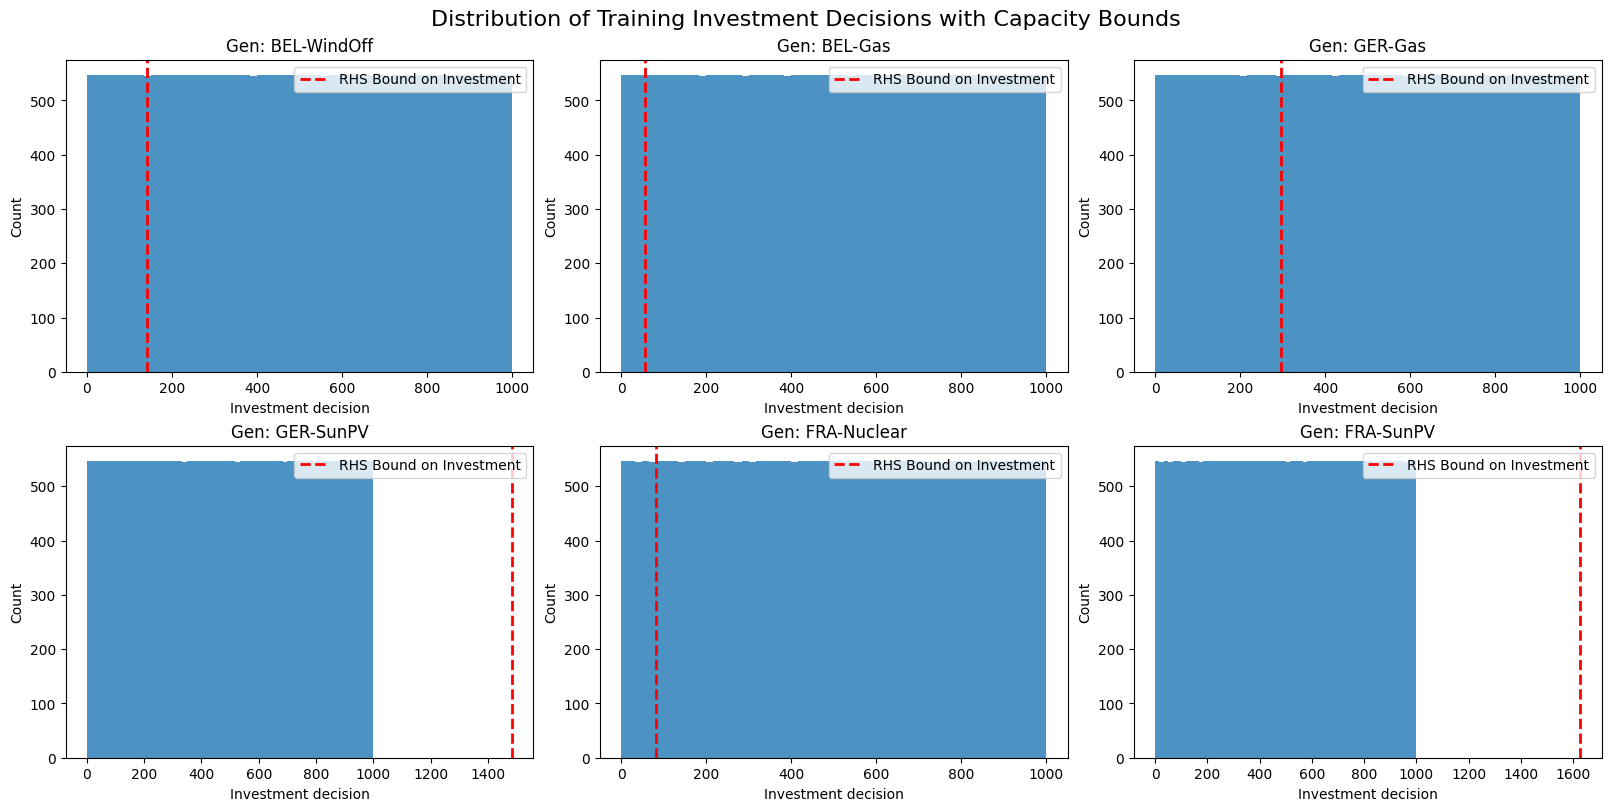

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Given / already in your notebook:
# generators = [('BEL', 'WindOff'), ('BEL', 'Gas'), ('GER', 'Gas'),
#               ('GER', 'SunPV'), ('FRA', 'Nuclear'), ('FRA', 'SunPV')]
# training_data.pUnitInvestment: torch.Size([32768, 6])
# u_rhs: shape (6,)  (torch tensor or numpy)

# --- Convert to numpy safely ---
X = training_data.pUnitInvestment
if hasattr(X, "detach"):
    X = X.detach().cpu().numpy()
else:
    X = np.asarray(X)

u = u_rhs
if hasattr(u, "detach"):
    u = u.detach().cpu().numpy()
else:
    u = np.asarray(u)

assert X.shape[1] == 6 and u.shape[0] == 6, (X.shape, u.shape)


fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
fig.suptitle(
    "Distribution of Training Investment Decisions with Capacity Bounds",
    fontsize=16
)

axes = axes.ravel()

for i, ax in enumerate(axes):
    gen = generators[i]
    vals = X[:, i]

    ax.hist(vals, bins=60, alpha=0.8)
    ax.axvline(u[i], linestyle="--", linewidth=2, color="red", label="RHS Bound on Investment")

    ax.set_title(f"Gen: {gen[0]}-{gen[1]}")
    ax.set_xlabel("Investment decision")
    ax.set_ylabel("Count")
    ax.legend()

plt.show()


# Dimension Reduction Comparision between Benders and Training Data

In [50]:
# kNN
nn = NearestNeighbors(n_neighbors=100).fit(X_training)
distances_test, _ = nn.kneighbors(X_test)
distances_benders, _ = nn.kneighbors(X_benders)

print(f"distances_test.mean(): {distances_test.mean()}")
print(f"np.median(distances_test): {np.median(distances_test)}")
print(f"distances_test.max(): {distances_test.max()}")

print(f"distances_benders.mean(): {distances_benders.mean()}")
print(f"np.median(distances_benders): {np.median(distances_benders)}")
print(f"distances_benders.max(): {distances_benders.max()}")

distances_test.mean(): 45041.94509336752
np.median(distances_test): 45618.42095083257
distances_test.max(): 90976.15219637356
distances_benders.mean(): 49907.09139020204
np.median(distances_benders): 51035.19416859659
distances_benders.max(): 90438.51741288803


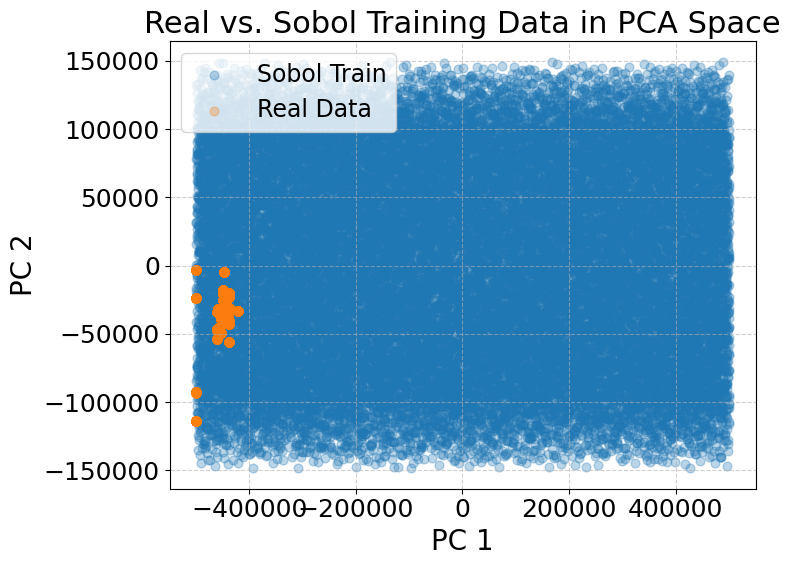

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA on the training (Sobol) data
pca = PCA(n_components=2)
pca.fit(X_training)

# Project both datasets using the same PCA basis
train_2d = pca.transform(X_training)
real_2d = pca.transform(X_benders)

plt.rcParams.update({
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,
    "font.size": 18
})

tab10 = plt.get_cmap("tab10")
train_color = tab10(0)  # blue
real_color = tab10(1)   # orange

plt.figure(figsize=(8, 6))
plt.scatter(train_2d[:, 0], train_2d[:, 1], alpha=0.3, label='Sobol Train', color=train_color, s=40, rasterized=True)
plt.scatter(real_2d[:, 0], real_2d[:, 1], alpha=0.3, label='Real Data', color=real_color, s=40, rasterized=True)
plt.legend(loc='best', frameon=True)
plt.title('Real vs. Sobol Training Data in PCA Space')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("figures/ch8-pca_real_vs_sobol.pdf", dpi=300, bbox_inches='tight')
plt.show()

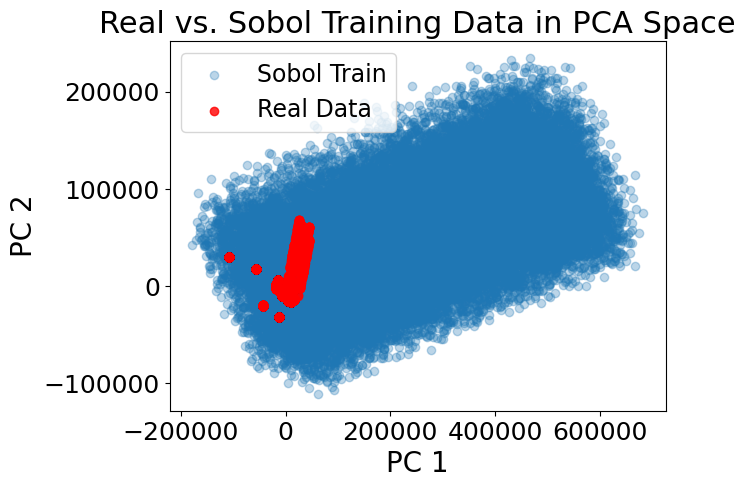

In [52]:
# Fit PCA on the training (Sobol) data
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca.fit(X_benders)

# Project both datasets using the same PCA basis
train_2d = pca.transform(X_training)
real_2d = pca.transform(X_benders)

# Plot both
plt.scatter(train_2d[:, 0], train_2d[:, 1], alpha=0.3, label='Sobol Train')
plt.scatter(real_2d[:, 0], real_2d[:, 1], alpha=0.8, label='Real Data', c='red')
plt.legend()
plt.title('Real vs. Sobol Training Data in PCA Space')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

In [53]:
import torch
from networks import DualClassificationNetEndToEnd, PrimalNetEndToEnd, PrimalNetEndToEnd2


path = "experiment-output/ch7/3nodes/dual_model"
with open(os.path.join(path, 'args.json'), 'r') as f:
        dual_args = json.load(f)
dual_net = DualClassificationNetEndToEnd(dual_args, data=training_data)
dual_net.load_state_dict(torch.load(os.path.join(path, 'dual_weights.pth'), weights_only=True))
dual_net.eval()

primal_path = "experiment-output/ch7/3nodes/primal_model"
with open(os.path.join(primal_path, 'args.json'), 'r') as f:
        primal_args = json.load(f)
#! Optuna args
best_args = {'primal_lr': 0.0006785456069117277, 'hidden_size_factor': 28, 'n_layers': 2, 'decay': 0.9989743016070536, 'batch_size': 2048}  #! Temporary, for primal net
primal_args["primal_lr"] = best_args["primal_lr"]
primal_args["hidden_size_factor"] = best_args["hidden_size_factor"]
primal_args["n_layers"] = best_args["n_layers"]
primal_args["decay"] = best_args["decay"]
primal_args["batch_size"] = best_args["batch_size"]
primal_net = PrimalNetEndToEnd2(primal_args, training_data)
primal_net.load_state_dict(torch.load(os.path.join(primal_path, "primal_weights.pth"), weights_only=True))
primal_net.eval()


pWeight = 120/8760 #! sample_duration = 120

mu_benders, lamb_benders = dual_net(X_benders)
Y_benders = primal_net(X_benders)

mu_benders/=pWeight
lamb_benders/=pWeight

mu_training, lamb_training = dual_net(X_training)
mu_test, lamb_test = dual_net(X_test)
Y_pred_training = primal_net(X_training)
Y_pred_test = primal_net(X_test)

dual_obj_benders = training_data.dual_obj_fn(X_benders, mu_benders, lamb_benders)
dual_opt_gap_benders = (dual_obj_benders - objs_benders) / objs_benders

dual_obj_training = training_data.dual_obj_fn(X_training, mu_training, lamb_training)
known_obj_training = training_data.dual_obj_fn(X_training, opt_mu_training, opt_lamb_training)
dual_opt_gap_training = (dual_obj_training - known_obj_training) / known_obj_training

dual_obj_test = training_data.dual_obj_fn(X_test, mu_test, lamb_test)
known_obj_test = training_data.dual_obj_fn(X_test, opt_mu_test, opt_lamb_test)
dual_opt_gap_test = (dual_obj_test - known_obj_test) / known_obj_test

primal_obj_benders = training_data.obj_fn(X_benders, Y_benders).detach().cpu().numpy() / pWeight
primal_opt_gap_benders = (primal_obj_benders - objs_benders) / objs_benders

primal_obj_training = training_data.obj_fn(X_training, Y_pred_training)
primal_opt_gap_training = ((primal_obj_training - known_obj_training) / known_obj_training).detach().cpu().numpy()

primal_obj_test = training_data.obj_fn(X_test, Y_pred_test)
primal_opt_gap_test = ((primal_obj_test - known_obj_test) / known_obj_test).detach().cpu().numpy()





print("Dual")
print(dual_opt_gap_benders.mean(), dual_opt_gap_benders.min(), dual_opt_gap_benders.max())
print(dual_opt_gap_training.mean(), dual_opt_gap_training.min(), dual_opt_gap_training.max())
print(dual_opt_gap_test.mean(), dual_opt_gap_test.min(), dual_opt_gap_test.max())

print("Primal")
print(primal_opt_gap_benders.mean(), primal_opt_gap_benders.min(), primal_opt_gap_benders.max())
print(primal_opt_gap_training.mean(), primal_opt_gap_training.min(), primal_opt_gap_training.max())
print(primal_opt_gap_test.mean(), primal_opt_gap_test.min(), primal_opt_gap_test.max())


Dual
tensor(-0.2872) tensor(-17.2146) tensor(3.4972e-16)
tensor(-0.0345) tensor(-96.2141) tensor(0.)
tensor(-0.0380) tensor(-26.8699) tensor(0.)
Primal
5.881595494987231 -5.809001034629497e-16 42.793011810137195
0.0020165538691994814 -1.0128286747284184e-15 8.458395277349554
0.007693726074487586 -2.1402925887882058e-16 10.004973194283183


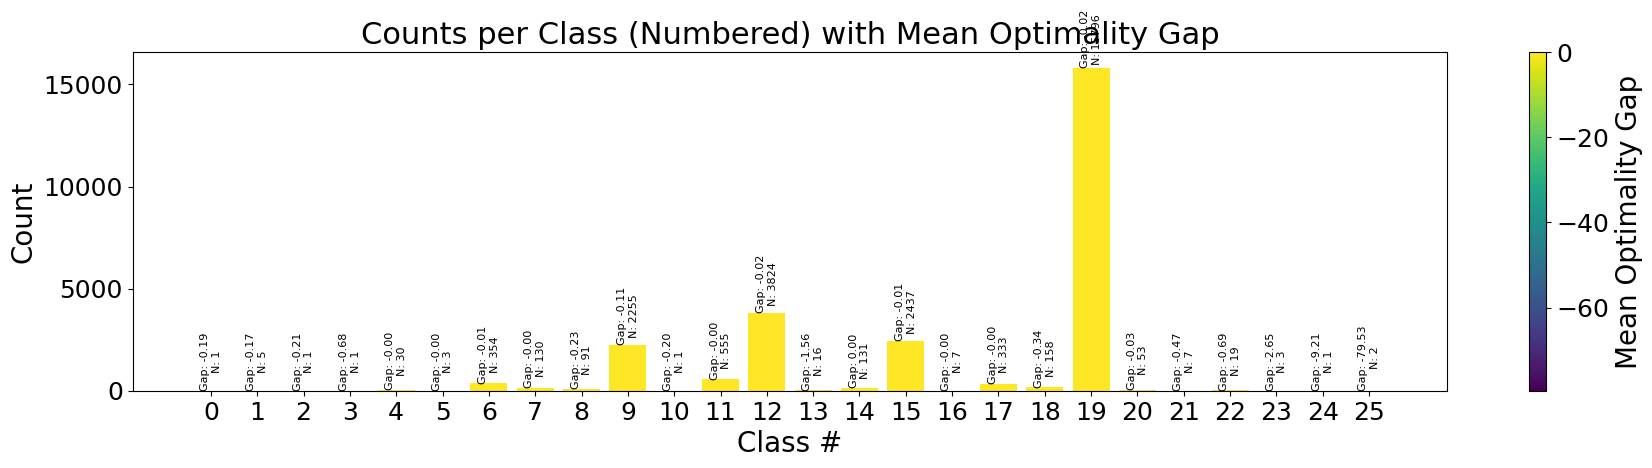

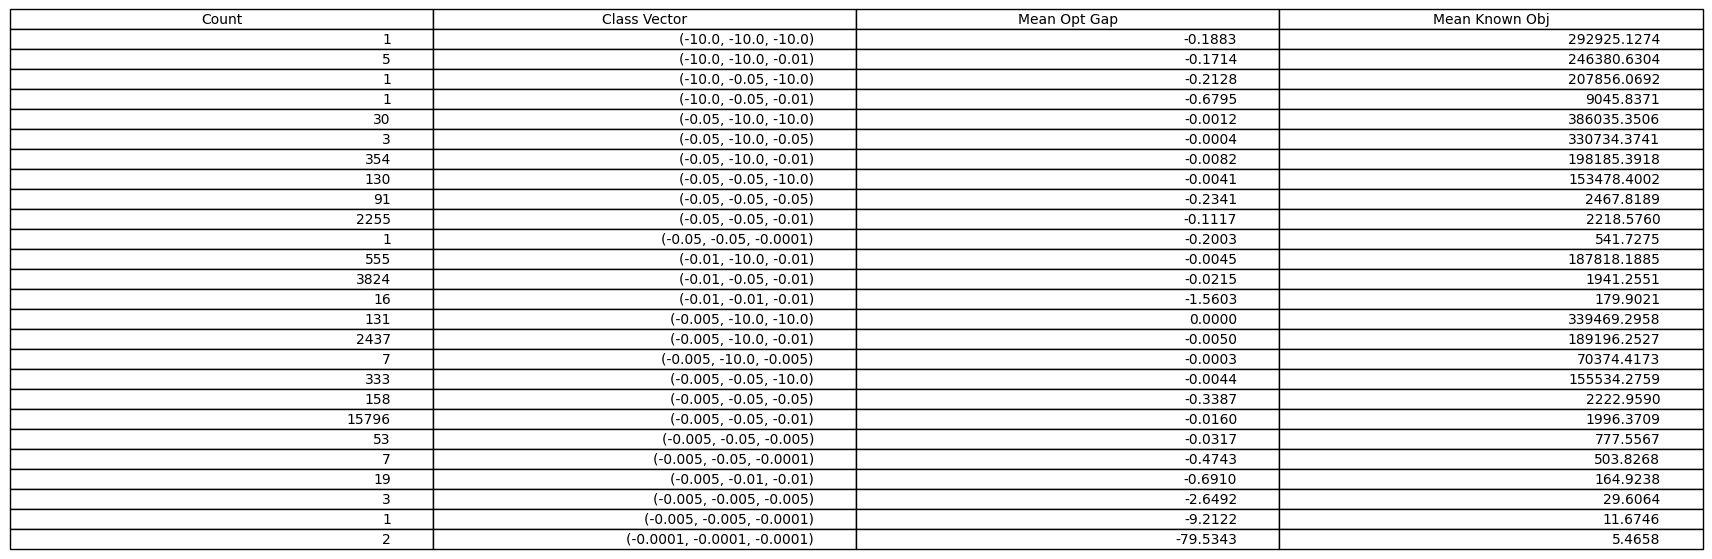

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Get unique classes and convert everything to numpy
classes = opt_lamb_training.unique(dim=0).detach().cpu().numpy()
target_lamb_np = opt_lamb_training.detach().cpu().numpy()
dual_opt_gap_np = dual_opt_gap_training.detach().cpu().numpy()
known_obj_np = known_obj_training.detach().cpu().numpy()

# Prepare storage
class_numbers = list(range(len(classes)))
opt_gap_classes = []
counts = []
known_obj_means = []
class_vectors = []

# Loop over classes and collect stats
for num, c in enumerate(classes):
    matches = np.all(target_lamb_np == c, axis=1)
    indices = np.where(matches)[0]
    count = len(indices)
    counts.append(count)
    class_vectors.append(tuple(float(x) for x in c))  # keep floats, not rounded
    if count > 0:
        mean_gap = dual_opt_gap_np[indices].mean()
        mean_known_obj = known_obj_np[indices].mean()
    else:
        mean_gap = np.nan
        mean_known_obj = np.nan
    opt_gap_classes.append(mean_gap)
    known_obj_means.append(mean_known_obj)

# Plot histogram with numbered classes
fig, ax = plt.subplots(figsize=(max(10, len(classes)*0.7), 5))
bars = ax.bar(
    class_numbers,
    counts,
    color=plt.cm.viridis(
        (np.array(opt_gap_classes) - np.nanmin(opt_gap_classes)) / (np.nanmax(opt_gap_classes) - np.nanmin(opt_gap_classes))
    )
)
ax.set_xticks(class_numbers)
ax.set_xticklabels(class_numbers, rotation=0)

sm = plt.cm.ScalarMappable(
    cmap='viridis',
    norm=plt.Normalize(vmin=np.nanmin(opt_gap_classes), vmax=np.nanmax(opt_gap_classes))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mean Optimality Gap')

# Print mean gap and count on each bar
for bar, gap, count in zip(bars, opt_gap_classes, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"Gap: {gap:.2f}\nN: {count}",
        ha='center', va='bottom', fontsize=8, rotation=90
    )

ax.set_xlabel('Class #')
ax.set_ylabel('Count')
ax.set_title('Counts per Class (Numbered) with Mean Optimality Gap')
plt.tight_layout()
plt.show()

# Build a table for display (with floats, not rounded)
table_data = [
    [
        counts[num],
        str(class_vectors[num]),  # tuple of floats
        f"{opt_gap_classes[num]:.4f}",
        f"{known_obj_means[num]:.4f}"
    ]
    for num in class_numbers
]
colLabels = ["Count", "Class Vector", "Mean Opt Gap", "Mean Known Obj"]

fig2, ax2 = plt.subplots(figsize=(max(10, len(classes)*0.7), 2))
ax2.axis('off')
table = ax2.table(
    cellText=table_data,
    colLabels=colLabels,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.show()

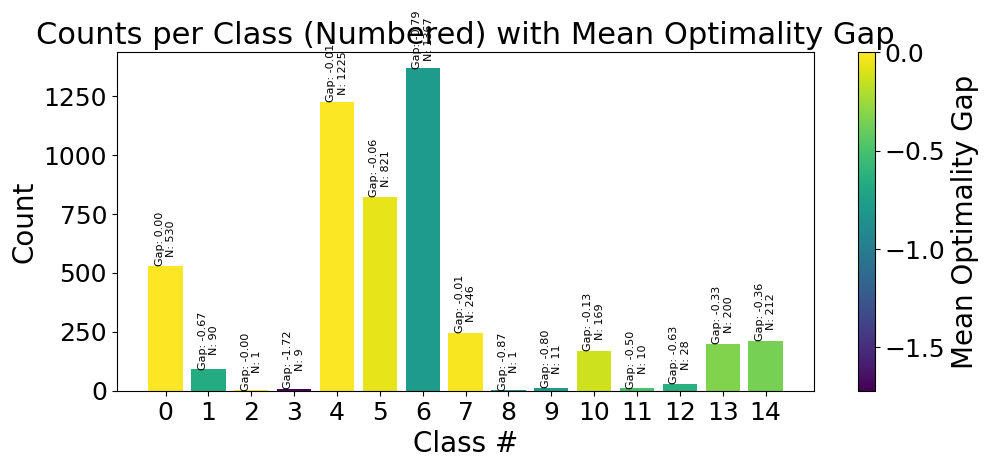

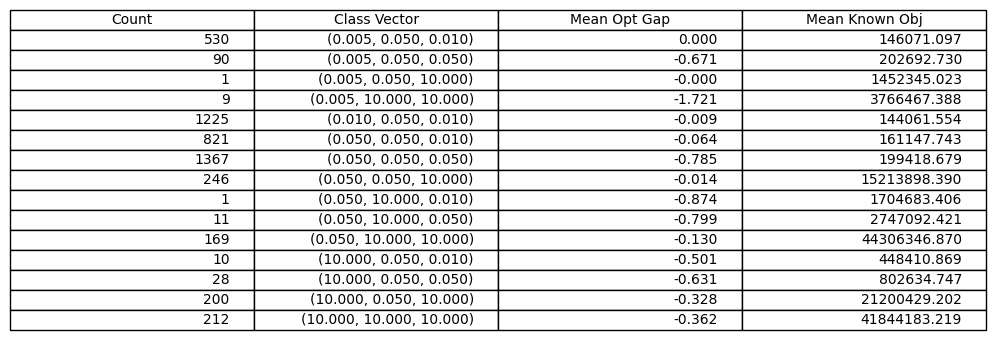

In [55]:
# Get unique classes and convert everything to numpy
pWeight = 120/8760

opt_lamb_benders = dual_solutions_benders[:, -training_data.num_n:] * pWeight
classes = torch.tensor(opt_lamb_benders).unique(dim=0).detach().cpu().numpy()
target_lamb_np = opt_lamb_benders
dual_opt_gap_np = dual_opt_gap_benders.detach().cpu().numpy()
known_obj_np = objs_benders

# Prepare storage
class_numbers = list(range(len(classes)))
opt_gap_classes = []
counts = []
known_obj_means = []
class_vectors = []

# Loop over classes and collect stats
for num, c in enumerate(classes):
    matches = np.all(target_lamb_np == c, axis=1)
    indices = np.where(matches)[0]
    count = len(indices)
    counts.append(count)
    class_vectors.append(tuple(float(x) for x in c))  # keep floats, not rounded
    if count > 0:
        mean_gap = dual_opt_gap_np[indices].mean()
        mean_known_obj = known_obj_np[indices].mean()
    else:
        mean_gap = np.nan
        mean_known_obj = np.nan
    opt_gap_classes.append(mean_gap)
    known_obj_means.append(mean_known_obj)

# Plot histogram with numbered classes
fig, ax = plt.subplots(figsize=(max(10, len(classes)*0.7), 5))
bars = ax.bar(
    class_numbers,
    counts,
    color=plt.cm.viridis(
        (np.array(opt_gap_classes) - np.nanmin(opt_gap_classes)) / (np.nanmax(opt_gap_classes) - np.nanmin(opt_gap_classes))
    )
)
ax.set_xticks(class_numbers)
ax.set_xticklabels(class_numbers, rotation=0)

sm = plt.cm.ScalarMappable(
    cmap='viridis',
    norm=plt.Normalize(vmin=np.nanmin(opt_gap_classes), vmax=np.nanmax(opt_gap_classes))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mean Optimality Gap')

# Print mean gap and count on each bar
for bar, gap, count in zip(bars, opt_gap_classes, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"Gap: {gap:.2f}\nN: {count}",
        ha='center', va='bottom', fontsize=8, rotation=90
    )

ax.set_xlabel('Class #')
ax.set_ylabel('Count')
ax.set_title('Counts per Class (Numbered) with Mean Optimality Gap')
plt.tight_layout()
plt.show()

# Build a table for display (with floats rounded to 5 decimals)
table_data = [
    [
        counts[num],
        "(" + ", ".join(f"{x:.3f}" for x in class_vectors[num]) + ")",  # tuple of floats, rounded to 3 decimals
        f"{opt_gap_classes[num]:.3f}",
        f"{known_obj_means[num]:.3f}"
    ]
    for num in class_numbers
]
colLabels = ["Count", "Class Vector", "Mean Opt Gap", "Mean Known Obj"]

fig2, ax2 = plt.subplots(figsize=(max(10, len(classes)*0.7), 2))
ax2.axis('off')
table = ax2.table(
    cellText=table_data,
    colLabels=colLabels,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.show()

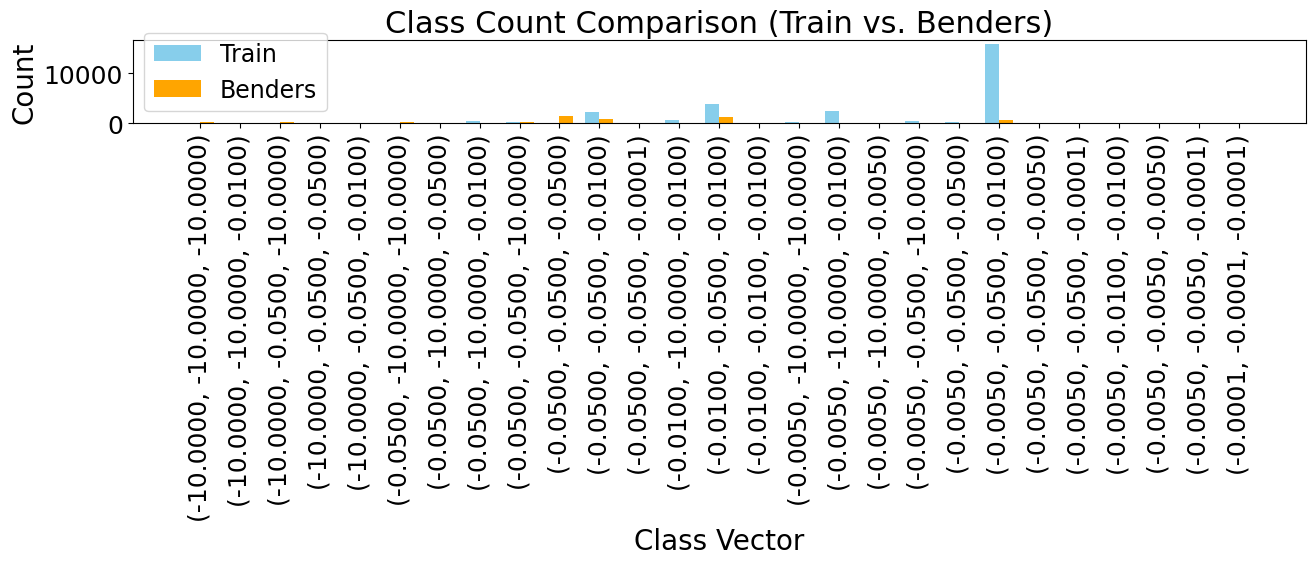

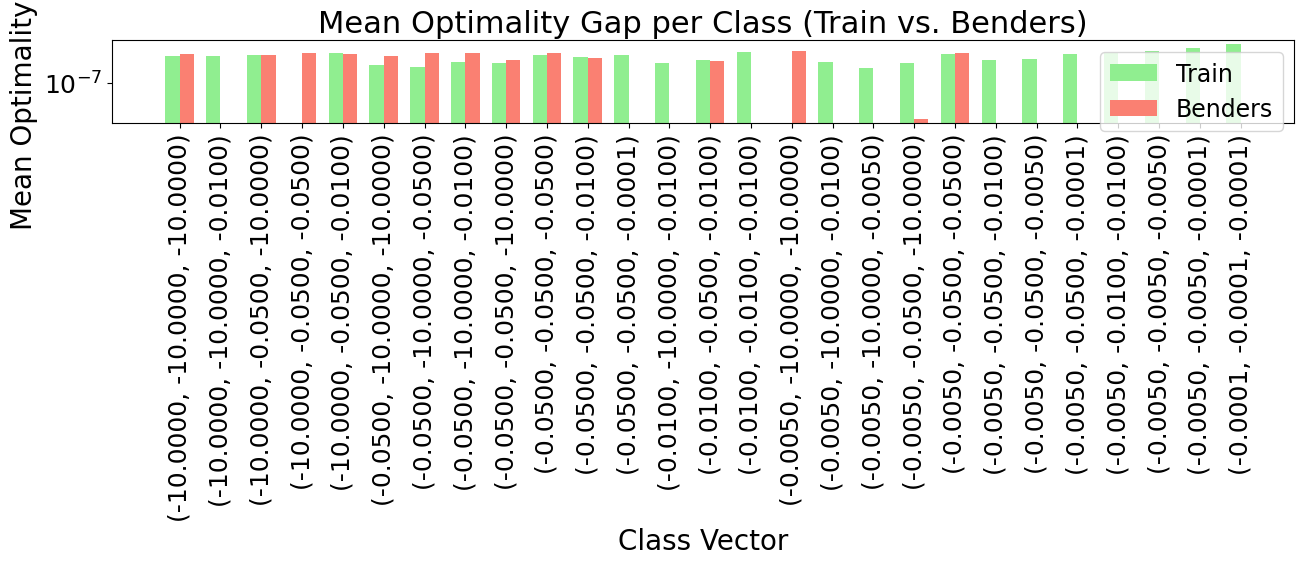

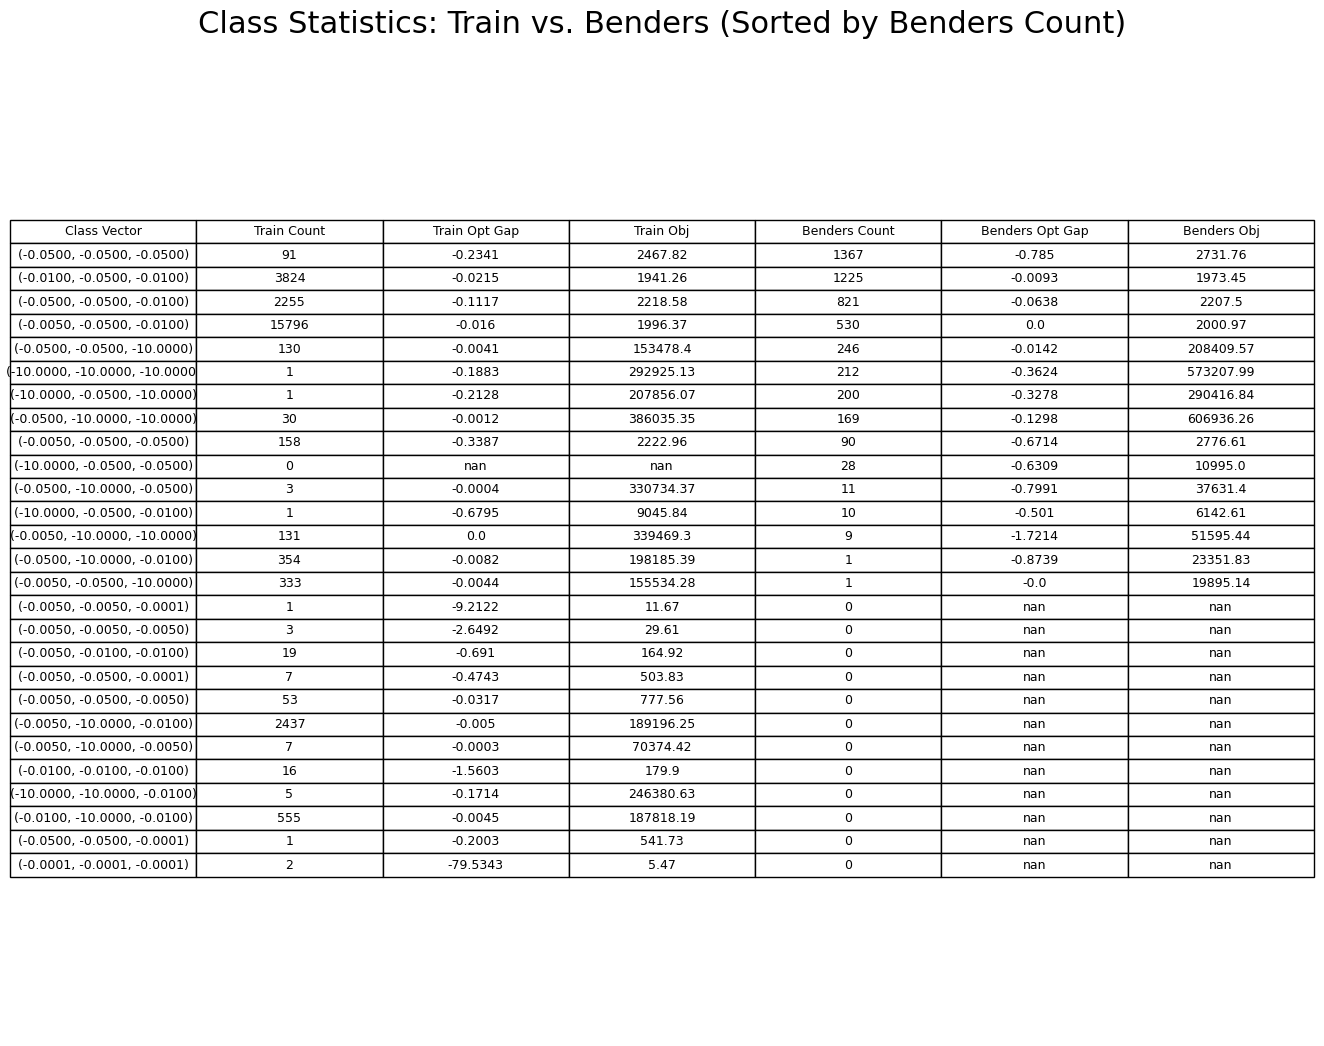

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Convert tensors to numpy ===
classes_train = opt_lamb_training.unique(dim=0).detach().cpu().numpy()
target_lamb_np = opt_lamb_training.detach().cpu().numpy()
dual_opt_gap_np = dual_opt_gap_training.detach().cpu().numpy()
known_obj_np = known_obj_training.detach().cpu().numpy()

pWeight = 120 / 8760
opt_lamb_benders_raw = (dual_solutions_benders[:, -training_data.num_n:] * pWeight)
opt_lamb_benders = np.round(-opt_lamb_benders_raw, decimals=5)  # Negate to match training
classes_benders = np.unique(opt_lamb_benders, axis=0)
dual_opt_gap_np_benders = dual_opt_gap_benders.detach().cpu().numpy()
known_obj_np_benders = objs_benders * pWeight

# === Build class stats dicts ===
def build_class_stats(classes, targets, gaps, objs):
    stats = {}
    for c in classes:
        c_tuple = tuple(c.tolist())
        matches = np.all(np.round(targets, 5) == c, axis=1)
        indices = np.where(matches)[0]
        if len(indices) > 0:
            stats[c_tuple] = {
                "count": len(indices),
                "mean_gap": float(gaps[indices].mean()),
                "mean_obj": float(objs[indices].mean())
            }
    return stats

train_stats = build_class_stats(classes_train, target_lamb_np, dual_opt_gap_np, known_obj_np)
benders_stats = build_class_stats(classes_benders, opt_lamb_benders, dual_opt_gap_np_benders, known_obj_np_benders)

# === Merge both stats ===
all_class_keys = set(train_stats) | set(benders_stats)
merged = []
for key in sorted(all_class_keys):
    row = {
        "Class Vector": key,
        "Count_Train": train_stats.get(key, {}).get("count", 0),
        "Mean Opt Gap_Train": train_stats.get(key, {}).get("mean_gap", np.nan),
        "Mean Known Obj_Train": train_stats.get(key, {}).get("mean_obj", np.nan),
        "Count_Benders": benders_stats.get(key, {}).get("count", 0),
        "Mean Opt Gap_Benders": benders_stats.get(key, {}).get("mean_gap", np.nan),
        "Mean Known Obj_Benders": benders_stats.get(key, {}).get("mean_obj", np.nan),
    }
    merged.append(row)

df = pd.DataFrame(merged)
df = df.sort_values(by="Class Vector")
df["Class Vector (str)"] = df["Class Vector"].apply(lambda x: f"({', '.join(f'{v:.4f}' for v in x)})")


# === Plot 1: Counts ===
x = np.arange(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.5), 6))
ax.bar(x - width / 2, df["Count_Train"], width, label="Train", color="skyblue")
ax.bar(x + width / 2, df["Count_Benders"], width, label="Benders", color="orange")

ax.set_xticks(x)
ax.set_xticklabels(df["Class Vector (str)"], rotation=90)
ax.set_ylabel("Count")
ax.set_xlabel("Class Vector")
ax.set_title("Class Count Comparison (Train vs. Benders)")
ax.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Mean Optimality Gap ===
fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.5), 6))
ax.bar(x - width / 2, -df["Mean Opt Gap_Train"], width, label="Train", color="lightgreen")
ax.bar(x + width / 2, -df["Mean Opt Gap_Benders"], width, label="Benders", color="salmon")

ax.set_xticks(x)
ax.set_xticklabels(df["Class Vector (str)"], rotation=90)
ax.set_ylabel("Mean Optimality Gap")
ax.set_xlabel("Class Vector")
ax.set_title("Mean Optimality Gap per Class (Train vs. Benders)")
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# === Plot 3: Entire table ===
# Round values for display
df_display = df[[
    "Class Vector (str)",
    "Count_Train", "Mean Opt Gap_Train", "Mean Known Obj_Train",
    "Count_Benders", "Mean Opt Gap_Benders", "Mean Known Obj_Benders"
]].copy()

# Sort by Benders count (descending)
df_display = df_display.sort_values(by="Count_Benders", ascending=False)

# Round for readability
df_display = df_display.round({
    "Mean Opt Gap_Train": 4,
    "Mean Known Obj_Train": 2,
    "Mean Opt Gap_Benders": 4,
    "Mean Known Obj_Benders": 2
})

# Set column labels
col_labels = [
    "Class Vector", 
    "Train Count", "Train Opt Gap", "Train Obj", 
    "Benders Count", "Benders Opt Gap", "Benders Obj"
]

# Plot the table
fig, ax = plt.subplots(figsize=(max(12, len(df_display) * 0.5), len(df_display) * 0.4))
ax.axis('off')

table = ax.table(
    cellText=df_display.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.2)

plt.title("Class Statistics: Train vs. Benders (Sorted by Benders Count)", pad=20)
plt.tight_layout()
plt.show()



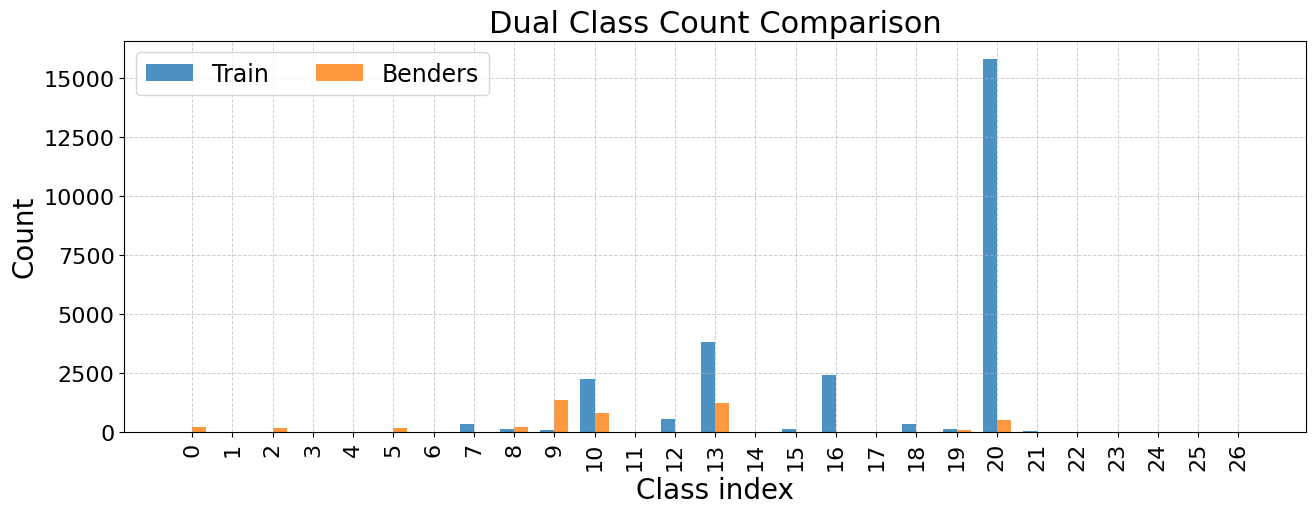

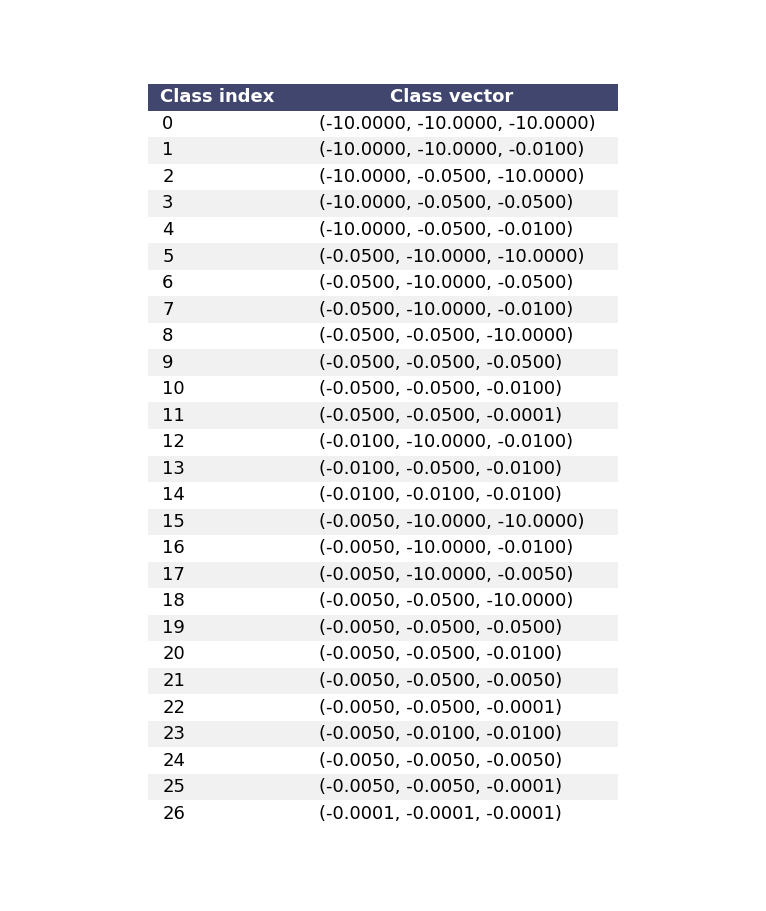

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Assume df is already created as in your code above
x = np.arange(len(df))
width = 0.35

plt.rcParams.update({
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 17,
    "font.size": 18
})

palette = plt.get_cmap("tab10")
train_color = palette(0)
benders_color = palette(1)

fig, ax = plt.subplots(figsize=(max(13, len(df) * 0.5), 6))

bars1 = ax.bar(x - width / 2, df["Count_Train"], width, label="Train", color=train_color, alpha=0.8)
bars2 = ax.bar(x + width / 2, df["Count_Benders"], width, label="Benders", color=benders_color, alpha=0.8)

for bar in bars1 + bars2:
    bar.set_rasterized(True)

ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90, ha='center')
ax.set_ylabel("Count")
ax.set_xlabel("Class index")
plt.yscale('log')
ax.set_title("Dual Class Count Comparison")
ax.legend(loc='upper left', ncol=2, frameon=True)
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.7, alpha=0.6)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(bottom=0.25)
plt.savefig("figures/ch8-class_count_comparison_thesis.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig, ax_table = plt.subplots(figsize=(max(8, len(df) * 0.25), len(df) * 0.35))
ax_table.axis('off')

# Prepare table data: index and class vector
table_data = [
    [idx, vec] for idx, vec in enumerate(df["Class Vector (str)"])
]
col_labels = ["Class index", "Class vector"]

table = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.3, 1.3)

# Format header and alternate row colors
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#40466e')
    else:
        if row % 2 == 0:
            cell.set_facecolor('#f1f1f2')
        else:
            cell.set_facecolor('white')
    cell.set_linewidth(0)

table.auto_set_column_width([0, 1])
plt.tight_layout()
plt.savefig("figures/ch8-class_index_vector_table.pdf", dpi=300, bbox_inches='tight')
plt.show()

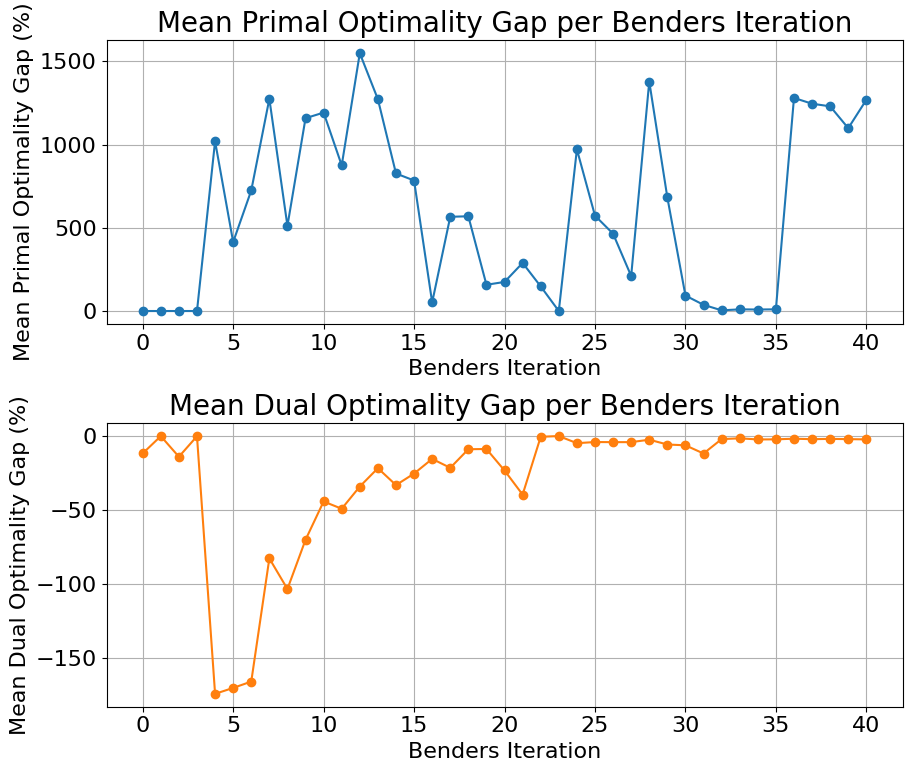

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Primal
group_size = 120
primal_opt_gap_np_benders = primal_opt_gap_benders
num_groups_primal = len(primal_opt_gap_np_benders) // group_size
grouped_means_primal = [
    np.mean(primal_opt_gap_np_benders[i * group_size:(i + 1) * group_size] * 100)
    for i in range(num_groups_primal)
]

# Dual
dual_opt_gap_np_benders = dual_opt_gap_benders.detach().cpu().numpy()
num_groups_dual = len(dual_opt_gap_np_benders) // group_size
grouped_means_dual = [
    np.mean(dual_opt_gap_np_benders[i * group_size:(i + 1) * group_size] * 100)
    for i in range(num_groups_dual)
]

plt.figure(figsize=(10, 8))
plt.rcParams.update({
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "font.size": 16
})

# Top: Primal
ax1 = plt.subplot(2, 1, 1)
ax1.plot(grouped_means_primal, marker='o', color='tab:blue')
ax1.set_xlabel("Benders Iteration")
ax1.set_ylabel("Mean Primal Optimality Gap (%)")
ax1.set_title("Mean Primal Optimality Gap per Benders Iteration")
ax1.grid(True)

# Bottom: Dual
ax2 = plt.subplot(2, 1, 2)
ax2.plot(grouped_means_dual, marker='o', color='tab:orange')
ax2.set_xlabel("Benders Iteration")
ax2.set_ylabel("Mean Dual Optimality Gap (%)")
ax2.set_title("Mean Dual Optimality Gap per Benders Iteration")
ax2.grid(True)

plt.tight_layout()
plt.subplots_adjust(left=0.18, hspace=0.35)  # Increase left margin and vertical space
plt.savefig("figures/ch8-benders_primal_dual_iteration_gaps_vertical.pdf", dpi=300, bbox_inches='tight')
plt.show()

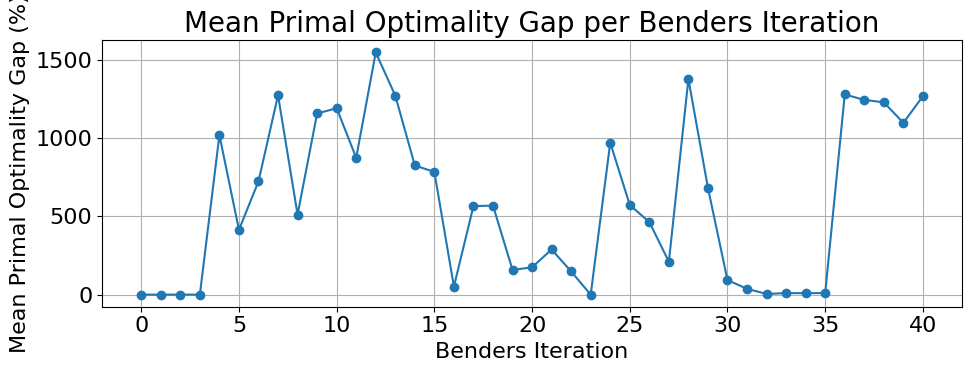

In [59]:
# Divide into groups of 120 and compute the mean for each group
group_size = 120
primal_opt_gap_np_benders = primal_opt_gap_benders
num_groups = len(primal_opt_gap_np_benders) // group_size

grouped_means = [
    np.mean(primal_opt_gap_np_benders[i * group_size:(i + 1) * group_size] * 100)
    for i in range(num_groups)
]

# Plot the means
plt.figure(figsize=(10, 4))
plt.plot(grouped_means, marker='o')
plt.xlabel("Benders Iteration")
plt.ylabel("Mean Primal Optimality Gap (%)")
plt.title("Mean Primal Optimality Gap per Benders Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()

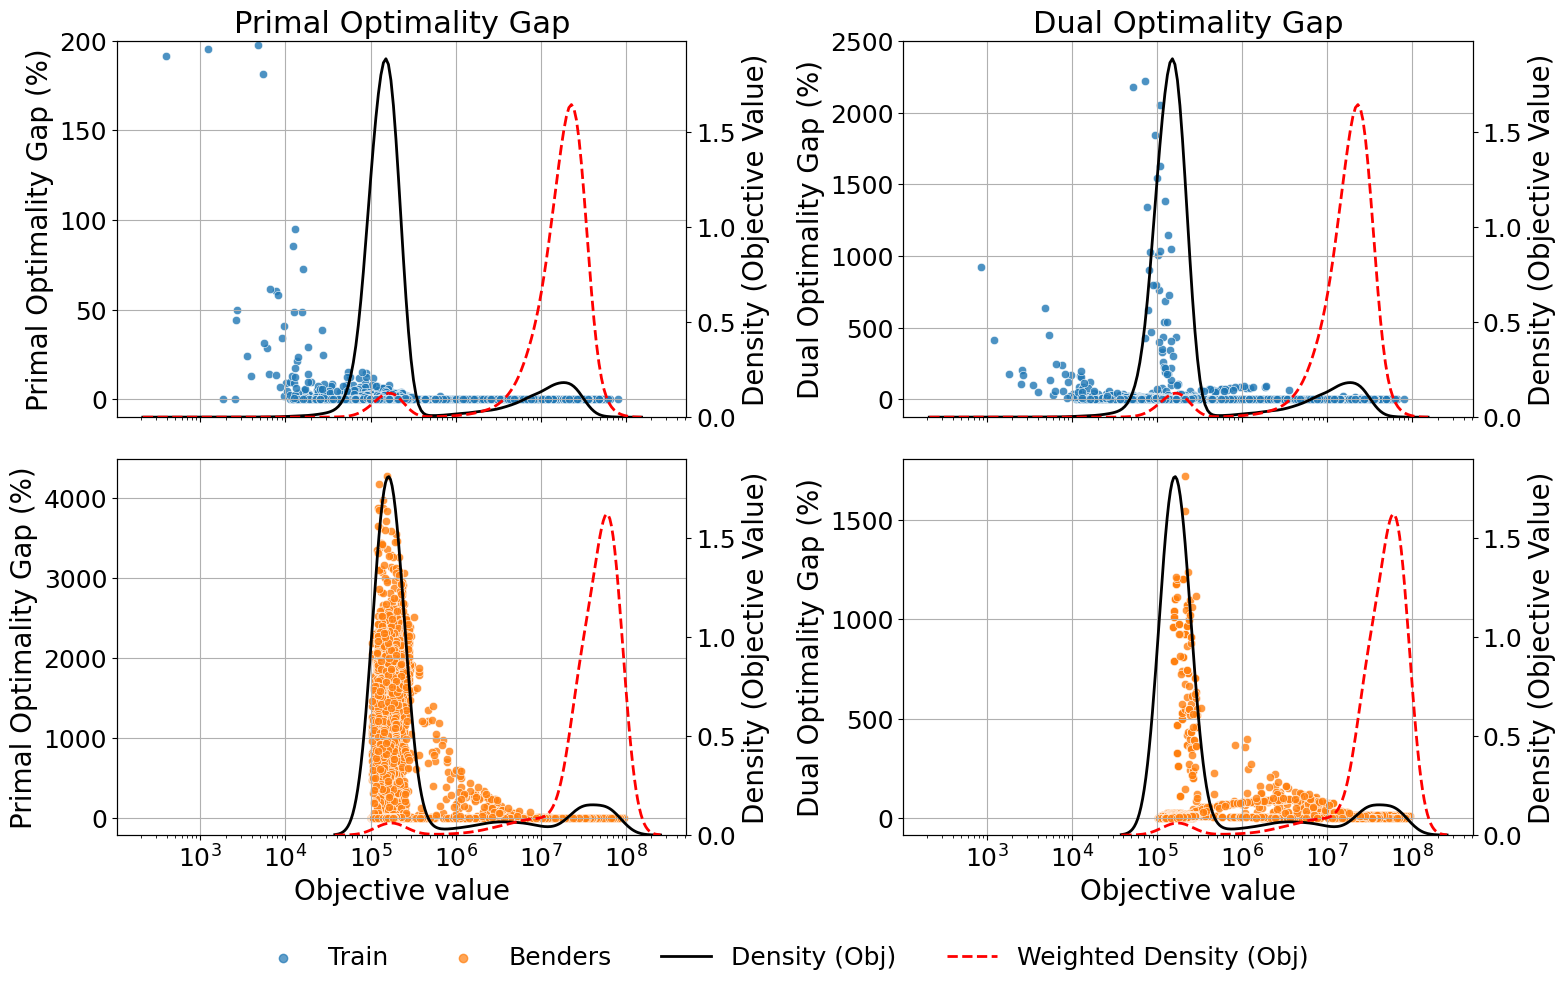

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,
    "font.size": 18
})
palette = plt.get_cmap("tab10")
palette = plt.get_cmap("tab10")
point_colors = [palette(0), palette(1)]  # blue, orange

# Data for each subplot: (x, y, title, y_label, point_color, dataset_label)
plot_data = [
    (known_obj_training / pWeight, primal_opt_gap_training * 100, "Primal", "Primal Optimality Gap (%)", point_colors[0], "Train"),
    (known_obj_training / pWeight, -dual_opt_gap_training * 100, "Dual", "Dual Optimality Gap (%)", point_colors[0], "Train"),
    (objs_benders, primal_opt_gap_benders * 100, "Primal", "Primal Optimality Gap (%)", point_colors[1], "Benders"),
    (objs_benders, -dual_opt_gap_benders * 100, "Dual", "Dual Optimality Gap (%)", point_colors[1], "Benders"),
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), sharex='col')

# For collecting legend handles/labels
handles = []
labels = []

# Create dummy scatter plots for legend (so they appear first)
dummy_train = plt.scatter([], [], color=point_colors[0], alpha=0.7, label="Train")
dummy_benders = plt.scatter([], [], color=point_colors[1], alpha=0.7, label="Benders")
handles.extend([dummy_train, dummy_benders])
labels.extend(["Train", "Benders"])

# We'll collect density handles/labels from the first subplot
density_handles = []
density_labels = []

for idx, (x, y, metric, y_label, color, dataset) in enumerate(plot_data):
    row = 0 if dataset == "Train" else 1
    col = 0 if metric == "Primal" else 1
    ax = axes[row, col]
    # Scatter plot (no legend)
    sns.scatterplot(
        x=x,
        y=y,
        sizes=(20, 200),
        ax=ax,
        color=color,
        alpha=0.8,
        rasterized=True,
        legend=False
    )
    ax.grid(True)

    if row == 0:
        ax.set_title(f"{metric} Optimality Gap")
    if col == 0:
        ax.set_ylabel(y_label)
    else:
        ax.set_ylabel(y_label)
    if row == 1:
        ax.set_xlabel("Objective value")
    ax.set_xscale('log')

    if row == 0 and col == 0:
        ax.set_ylim(-200*0.05, 200)
    
    if row == 0 and col == 1:
        ax.set_ylim(-2500*0.05, 2500)

    # Secondary y-axis for density
    axb = ax.twinx()
    # Only add density labels/handles for the first subplot
    if row == 0 and col == 0:
        density_line = sns.kdeplot(
            x=x,
            ax=axb,
            color='black',
            linewidth=2,
            label="Density (Obj)",
            legend=False
        )
        weighted_line = sns.kdeplot(
            x=x,
            weights=x,
            ax=axb,
            color='red',
            linewidth=2,
            linestyle='--',
            label="Weighted Density (Obj)",
            legend=False
        )
        h2, l2 = axb.get_legend_handles_labels()
        density_handles.extend(h2)
        density_labels.extend(l2)
    else:
        sns.kdeplot(
            x=x,
            ax=axb,
            color='black',
            linewidth=2,
            legend=False
        )
        sns.kdeplot(
            x=x,
            weights=x,
            ax=axb,
            color='red',
            linewidth=2,
            linestyle='--',
            legend=False
        )
    axb.set_ylabel("Density (Objective Value)")

# Add density lines to the legend after the scatter handles
handles.extend(density_handles)
labels.extend(density_labels)

# Place a single legend below all subplots
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=18, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("figures/ch8-optimality-gap-distribution.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [61]:
training_data.pGenAva

{('AUS', 'SunPV', 1): 0.0,
 ('AUS', 'SunPV', 2): 0.0,
 ('AUS', 'SunPV', 3): 0.0,
 ('AUS', 'SunPV', 4): 0.0,
 ('AUS', 'SunPV', 5): 0.0,
 ('AUS', 'SunPV', 6): 0.0,
 ('AUS', 'SunPV', 7): 0.0,
 ('AUS', 'SunPV', 8): 0.01,
 ('AUS', 'SunPV', 9): 0.088,
 ('AUS', 'SunPV', 10): 0.107,
 ('AUS', 'SunPV', 11): 0.097,
 ('AUS', 'SunPV', 12): 0.096,
 ('AUS', 'SunPV', 13): 0.081,
 ('AUS', 'SunPV', 14): 0.076,
 ('AUS', 'SunPV', 15): 0.048,
 ('AUS', 'SunPV', 16): 0.005,
 ('AUS', 'SunPV', 17): 0.0,
 ('AUS', 'SunPV', 18): 0.0,
 ('AUS', 'SunPV', 19): 0.0,
 ('AUS', 'SunPV', 20): 0.0,
 ('AUS', 'SunPV', 21): 0.0,
 ('AUS', 'SunPV', 22): 0.0,
 ('AUS', 'SunPV', 23): 0.0,
 ('AUS', 'SunPV', 24): 0.0,
 ('AUS', 'SunPV', 25): 0.0,
 ('AUS', 'SunPV', 26): 0.0,
 ('AUS', 'SunPV', 27): 0.0,
 ('AUS', 'SunPV', 28): 0.0,
 ('AUS', 'SunPV', 29): 0.0,
 ('AUS', 'SunPV', 30): 0.0,
 ('AUS', 'SunPV', 31): 0.0,
 ('AUS', 'SunPV', 32): 0.017,
 ('AUS', 'SunPV', 33): 0.13,
 ('AUS', 'SunPV', 34): 0.233,
 ('AUS', 'SunPV', 35): 0.289,
 ('AU

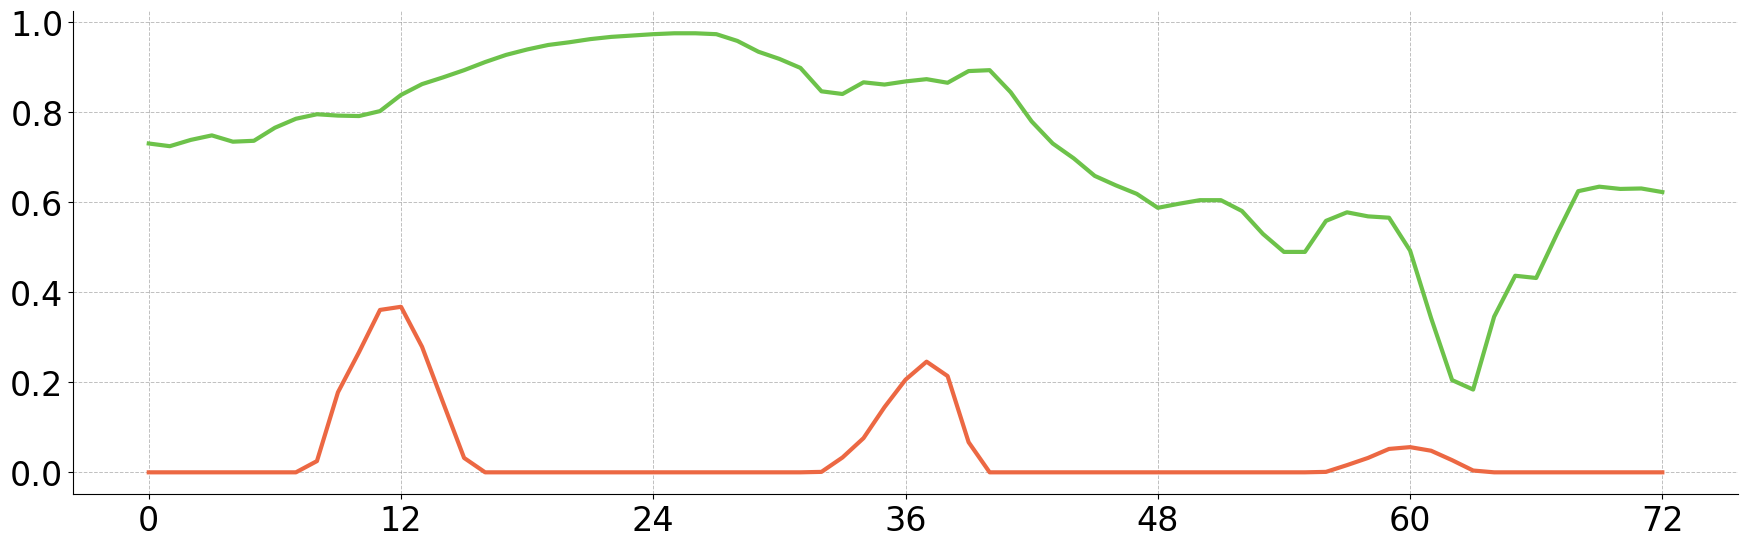

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Set global font sizes for a professional look
plt.rcParams.update({
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24,
    "font.size": 24
})

profiles = {}
until = 73
techs = ["SunPV", "WindOff"]
for tech in techs:
    profiles[tech] = []
    for i in range(1, until+1):
        profiles[tech].append(training_data.pGenAva[("BEL", tech, i)])

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(profiles["SunPV"], color='#EC6843', linewidth=3, label="SunPV")
ax.plot(profiles["WindOff"], color='#6DC24A', linewidth=3, label="WindOff")

# Set x-ticks every 12
xticks = np.arange(0, until, 12)
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks])

# Show y-axis and all spines
ax.yaxis.set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(True)

# Add a very faint grid
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.7, alpha=0.5, color='gray')

plt.tight_layout()
plt.savefig("bel_sun_wind_profiles.svg", format="svg", bbox_inches='tight', transparent=True)
plt.show()